Prije pokretanja kaggle učitavanja potrebno je učitati .json za kaggle API OAuth key

# 1. Učitavanje dataseta

In [1]:
!pip install kaggle

In [2]:
import os

if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

!mv /content/sample_data/kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

print('Kaggle authentication successful!')

Kaggle authentication successful!


In [3]:
!kaggle competitions download -c home-credit-default-risk
!mkdir -p data/raw
!unzip home-credit-default-risk.zip -d data/raw

100% 688M/688M [00:08<00:00, 89.7MB/s]

Archive:  home-credit-default-risk.zip
  inflating: data/raw/HomeCredit_columns_description.csv  
  inflating: data/raw/POS_CASH_balance.csv  
  inflating: data/raw/application_test.csv  
  inflating: data/raw/application_train.csv  
  inflating: data/raw/bureau.csv     
  inflating: data/raw/bureau_balance.csv  
  inflating: data/raw/credit_card_balance.csv  
  inflating: data/raw/installments_payments.csv  
  inflating: data/raw/previous_application.csv  
  inflating: data/raw/sample_submission.csv  


## 1.1. Brisanje nepotrebnih tablica

In [4]:
import os

directory = 'data/raw/'
files_to_keep = [
    'application_train.csv',
    'bureau.csv',
    'previous_application.csv',
    'installments_payments.csv'
]

for filename in os.listdir(directory):
    if filename not in files_to_keep:
        file_path = os.path.join(directory, filename)
        os.remove(file_path)
        print(f'Deleted: {file_path}')

print('Deletion process complete.')

Deleted: data/raw/bureau_balance.csv
Deleted: data/raw/credit_card_balance.csv
Deleted: data/raw/application_test.csv
Deleted: data/raw/POS_CASH_balance.csv
Deleted: data/raw/HomeCredit_columns_description.csv
Deleted: data/raw/sample_submission.csv
Deletion process complete.


# 2. Dimenzije tablica

In [5]:
import pandas as pd
import os

directory = 'data/raw/'
files_to_keep = [
    'application_train.csv',
    'bureau.csv',
    'previous_application.csv',
    'installments_payments.csv'
]

print("Shape of each remaining table:")
for filename in files_to_keep:
    file_path = os.path.join(directory, filename)
    try:
        df = pd.read_csv(file_path)
        print(f"{filename}: {df.shape}")
    except Exception as e:
        print(f"Error reading {filename}: {e}")

Shape of each remaining table:
application_train.csv: (307511, 122)
bureau.csv: (1716428, 17)
previous_application.csv: (1670214, 37)
installments_payments.csv: (13605401, 8)


1. Glavna tablica (application_train.csv - trenutna kreditna aplikacija) sadrži 122 stupca 307 511 redova
2. bureau.csv (kreditna povijest iz drugih fin. institucija) sadrži 17 stupaca 1 716 428 redaka
3. previous_application.csv (tablica prethodnih kreditnih aplikacija istog klijenta kod Home Credita) sadrži 37 stupaca i 1 670 214 redaka
4. installments_payments (tablica povijesti otplate prethodnih kredita) sadrži 8 stupaca i čak 13 605 401 redaka, i njena veličina će postavljati potencijalni problem (za treniranje modela na lošijoj arhitekturi) ako nije smanjena

# 3. Objašnjenje tablica (kroz interpretaciju prvih par redova)

In [6]:
directory = 'data/raw/'
file_path = os.path.join(directory, 'application_train.csv')

try:
    df_application_train = pd.read_csv(file_path)
    print(df_application_train.head())
except Exception as e:
    print(f"Error reading application_train.csv: {e}")

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             

Tablica application_train.csv predstavlja glavnu tablicu podataka o trenutnim kreditnim aplikacijama klijenata. Svaki redak u ovoj tablici odgovara jednoj kreditnoj prijavi, a stupci opisuju različite karakteristike podnositelja zahtjeva i same aplikacije. Najvažniji stupci su:
1. SK_ID_CURR — ID trenutnog klijenta/aplikacije
2. TARGET — ciljna varijabla (1 - poteškoće, 0 - bez poteškoća)
3. AMT_INCOME_TOTAL — prihod klijenta
4. AMT_CREDIT — iznos kredita
5. AMT_ANNUITY — anuitet
6. demografski i financijski podaci klijenta

In [7]:
directory = 'data/raw/'
file_path = os.path.join(directory, 'bureau.csv')

try:
    df_bureau = pd.read_csv(file_path)
    print(df_bureau.head())
except Exception as e:
    print(f"Error reading bureau.csv: {e}")

   SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY  DAYS_CREDIT  \
0      215354       5714462        Closed      currency 1         -497   
1      215354       5714463        Active      currency 1         -208   
2      215354       5714464        Active      currency 1         -203   
3      215354       5714465        Active      currency 1         -203   
4      215354       5714466        Active      currency 1         -629   

   CREDIT_DAY_OVERDUE  DAYS_CREDIT_ENDDATE  DAYS_ENDDATE_FACT  \
0                   0               -153.0             -153.0   
1                   0               1075.0                NaN   
2                   0                528.0                NaN   
3                   0                  NaN                NaN   
4                   0               1197.0                NaN   

   AMT_CREDIT_MAX_OVERDUE  CNT_CREDIT_PROLONG  AMT_CREDIT_SUM  \
0                     NaN                   0         91323.0   
1                     NaN         

Tablica bureau.csv sadrži informacije o prošlim kreditima koje su klijenti Home Credita imali u drugim financijskim institucijama. Svaki redak u ovoj tablici predstavlja jedan kredit iz povijesti klijenta. Jedan klijent može imati više zapisa u ovoj tablici.
Primjeri korisnih featurea:
1. broj prethodnih kredita,
2. broj aktivnih kredita,
3. broj zatvorenih kredita,
4. ukupni prethodni kreditni iznos,
5. ukupni dug,
6. omjer duga i prethodno odobrenih kredita.

Veza s glavnom tablicom:
application_train.SK_ID_CURR = bureau.SK_ID_CURR

In [8]:
directory = 'data/raw/'
file_path = os.path.join(directory, 'previous_application.csv')

try:
    df_previous_application = pd.read_csv(file_path)
    print(df_previous_application.head())
except Exception as e:
    print(f"Error reading previous_application.csv: {e}")

   SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_TYPE  AMT_ANNUITY  AMT_APPLICATION  \
0     2030495      271877     Consumer loans     1730.430          17145.0   
1     2802425      108129         Cash loans    25188.615         607500.0   
2     2523466      122040         Cash loans    15060.735         112500.0   
3     2819243      176158         Cash loans    47041.335         450000.0   
4     1784265      202054         Cash loans    31924.395         337500.0   

   AMT_CREDIT  AMT_DOWN_PAYMENT  AMT_GOODS_PRICE WEEKDAY_APPR_PROCESS_START  \
0     17145.0               0.0          17145.0                   SATURDAY   
1    679671.0               NaN         607500.0                   THURSDAY   
2    136444.5               NaN         112500.0                    TUESDAY   
3    470790.0               NaN         450000.0                     MONDAY   
4    404055.0               NaN         337500.0                   THURSDAY   

   HOUR_APPR_PROCESS_START  ... NAME_SELLER_INDUSTRY  CN

Tablica previous_application.csv sadrži podatke o prethodnim kreditnim aplikacijama koje su klijenti Home Credita podnijeli izravno u Home Creditu. Svaki redak u ovoj tablici odgovara jednoj prethodnoj aplikaciji. Jedan klijent može imati više prethodnih aplikacija. Primjeri korisnih featurea:
1. broj prethodnih aplikacija,
2. broj odobrenih aplikacija,
3. broj odbijenih aplikacija,
4. udio odbijenih aplikacija,
5. prosječan traženi iznos,
6. prosječan odobreni iznos,
7. omjer odobrenog i traženog iznosa.


Veza s glavnom tablicom:
application_train.SK_ID_CURR = previous_application.SK_ID_CURR

In [9]:
directory = 'data/raw/'
file_path = os.path.join(directory, 'installments_payments.csv')

try:
    df_installments_payments = pd.read_csv(file_path)
    print(df_installments_payments.head())
except Exception as e:
    print(f"Error reading installments_payments.csv: {e}")

   SK_ID_PREV  SK_ID_CURR  NUM_INSTALMENT_VERSION  NUM_INSTALMENT_NUMBER  \
0     1054186      161674                     1.0                      6   
1     1330831      151639                     0.0                     34   
2     2085231      193053                     2.0                      1   
3     2452527      199697                     1.0                      3   
4     2714724      167756                     1.0                      2   

   DAYS_INSTALMENT  DAYS_ENTRY_PAYMENT  AMT_INSTALMENT  AMT_PAYMENT  
0          -1180.0             -1187.0        6948.360     6948.360  
1          -2156.0             -2156.0        1716.525     1716.525  
2            -63.0               -63.0       25425.000    25425.000  
3          -2418.0             -2426.0       24350.130    24350.130  
4          -1383.0             -1366.0        2165.040     2160.585  


Tablica installments_payments.csv sadrži povijest otplate rata za prethodne kredite koje su klijenti imali kod Home Credita. Svaki redak u ovoj tablici predstavlja jednu planiranu ili stvarnu otplatu rate. Ova tablica bilježi detalje o tome kako su klijenti plaćali svoje rate, uključujući iznose i datume.
Jedan klijent može imati više prethodnih aplikacija.
Primjeri korisnih featurea:
1. broj rata,
2. broj zakašnjelih rata,
3. udio zakašnjelih rata,
4. prosječno kašnjenje plaćanja,
5. maksimalno kašnjenje plaćanja,
6. omjer stvarno plaćenog i planiranog iznosa,
7. broj djelomično plaćenih rata.


Veza s glavnom tablicom:
application_train.SK_ID_CURR = previous_application.SK_ID_CURR


# 4. Provjera tipova podataka

# 4.1. Application_train (glavna)

In [10]:
df_application_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


Tablica application_train sadrži 122 stupca, toliko ih je da ih čak ni info ne prikazuje, ovo ne smije ostati ovako i mora se smanjiti na najvažnije stupce:
1. SK_ID_CURR — ID trenutnog klijenta/aplikacije
2. TARGET — ciljna varijabla
3. AMT_INCOME_TOTAL — prihod klijenta
4. AMT_CREDIT — iznos kredita
5. AMT_ANNUITY — anuitet
6. demografski i financijski podaci klijenta

In [11]:
selected_columns = [
    'SK_ID_CURR',
    'TARGET',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'REGION_POPULATION_RELATIVE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'NAME_INCOME_TYPE',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'AMT_GOODS_PRICE'
]

df_application_train_filtered = df_application_train[selected_columns].copy()

print("--- Info for filtered application_train.csv ---")
df_application_train_filtered.info()
df_application_train_filtered.head()

--- Info for filtered application_train.csv ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   SK_ID_CURR                  307511 non-null  int64  
 1   TARGET                      307511 non-null  int64  
 2   AMT_INCOME_TOTAL            307511 non-null  float64
 3   AMT_CREDIT                  307511 non-null  float64
 4   AMT_ANNUITY                 307499 non-null  float64
 5   NAME_CONTRACT_TYPE          307511 non-null  object 
 6   CODE_GENDER                 307511 non-null  object 
 7   FLAG_OWN_CAR                307511 non-null  object 
 8   FLAG_OWN_REALTY             307511 non-null  object 
 9   CNT_CHILDREN                307511 non-null  int64  
 10  CNT_FAM_MEMBERS             307509 non-null  float64
 11  NAME_EDUCATION_TYPE         307511 non-null  object 
 12  NAME_FAMILY_STATUS      

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,NAME_INCOME_TYPE,NAME_HOUSING_TYPE,OCCUPATION_TYPE,AMT_GOODS_PRICE
0,100002,1,202500.0,406597.5,24700.5,Cash loans,M,N,Y,0,1.0,Secondary / secondary special,Single / not married,0.018801,-9461,-637,Working,House / apartment,Laborers,351000.0
1,100003,0,270000.0,1293502.5,35698.5,Cash loans,F,N,N,0,2.0,Higher education,Married,0.003541,-16765,-1188,State servant,House / apartment,Core staff,1129500.0
2,100004,0,67500.0,135000.0,6750.0,Revolving loans,M,Y,Y,0,1.0,Secondary / secondary special,Single / not married,0.010032,-19046,-225,Working,House / apartment,Laborers,135000.0
3,100006,0,135000.0,312682.5,29686.5,Cash loans,F,N,Y,0,2.0,Secondary / secondary special,Civil marriage,0.008019,-19005,-3039,Working,House / apartment,Laborers,297000.0
4,100007,0,121500.0,513000.0,21865.5,Cash loans,M,N,Y,0,1.0,Secondary / secondary special,Single / not married,0.028663,-19932,-3038,Working,House / apartment,Core staff,513000.0


Ostalo je samo 19 značajki, što je kombinirano s drugim tablicama još uvijek previše za treniranje modela no još neće biti izbacivane dok se ne analizira korelacija s ciljnom varijablom


In [12]:
df_application_train = df_application_train[selected_columns].copy()

df_application_train['FLAG_OWN_CAR'] = df_application_train['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
df_application_train['FLAG_OWN_REALTY'] = df_application_train['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})

categorical_cols = df_application_train.select_dtypes(include='object').columns

df_application_train = pd.get_dummies(df_application_train, columns=categorical_cols, dummy_na=False)

print("--- Info for df_application_train after filtering and encoding ---")
df_application_train.info()
print("\n--- Head of df_application_train after filtering and encoding ---")
print(df_application_train.head())

--- Info for df_application_train after filtering and encoding ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 61 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   SK_ID_CURR                                         307511 non-null  int64  
 1   TARGET                                             307511 non-null  int64  
 2   AMT_INCOME_TOTAL                                   307511 non-null  float64
 3   AMT_CREDIT                                         307511 non-null  float64
 4   AMT_ANNUITY                                        307499 non-null  float64
 5   FLAG_OWN_CAR                                       307511 non-null  int64  
 6   FLAG_OWN_REALTY                                    307511 non-null  int64  
 7   CNT_CHILDREN                                       307511 non-null  int64  
 8   CNT_FAM

Zbog one hot enkodiranja broj značajki je ponovno eksplodirao, pričekat ću s izbacivanjem varijabli do analize korelacije ili potencijalno još kasnije, ali ovo predstavlja prepreku prije treniranja.

# 4.2. Bureau

In [13]:
df_bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


Uočene su 3 object varijable koje su pretvorene u odgovarajuće formate:

In [14]:
import pandas as pd

categorical_cols_bureau = df_bureau.select_dtypes(include='object').columns

df_bureau = pd.get_dummies(df_bureau, columns=categorical_cols_bureau, dummy_na=False)

print("--- Info for df_bureau after encoding categorical variables ---")
df_bureau.info()
print("\n--- Head of df_bureau after encoding ---")
print(df_bureau.head())

--- Info for df_bureau after encoding categorical variables ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 37 columns):
 #   Column                                                    Dtype  
---  ------                                                    -----  
 0   SK_ID_CURR                                                int64  
 1   SK_ID_BUREAU                                              int64  
 2   DAYS_CREDIT                                               int64  
 3   CREDIT_DAY_OVERDUE                                        int64  
 4   DAYS_CREDIT_ENDDATE                                       float64
 5   DAYS_ENDDATE_FACT                                         float64
 6   AMT_CREDIT_MAX_OVERDUE                                    float64
 7   CNT_CREDIT_PROLONG                                        int64  
 8   AMT_CREDIT_SUM                                            float64
 9   AMT_CREDIT_SUM_DEBT                  

Nakon enkodiranja dobiveno je 37 značajki, još ih se ne izbacuje dok se ne povežu preko ključa na target i dok se ne analizira korelacija s targetom.

# 4.3. Previous_application

In [15]:
df_previous_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

37 neenkodiranih značajki je previše, zadržavamo značajke koje su potrebne da se izračunaju prethodno identificirane najvažnije značajke:
1. broj prethodnih aplikacija,
2. broj odobrenih aplikacija,
3. broj odbijenih aplikacija,
4. udio odbijenih aplikacija,
5. prosječan traženi iznos,
6. prosječan odobreni iznos,
7. omjer odobrenog i traženog iznosa.


Ostale se izbacuje:

In [16]:
selected_cols_previous_app = [
    'SK_ID_PREV',
    'SK_ID_CURR',
    'NAME_CONTRACT_STATUS',
    'AMT_APPLICATION',
    'AMT_CREDIT'
]

df_previous_application = df_previous_application[selected_cols_previous_app].copy()

print("--- Info for df_previous_application after filtering ---")
df_previous_application.info()
print("\n--- Head of df_previous_application after filtering ---")
print(df_previous_application.head())

--- Info for df_previous_application after filtering ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 5 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   SK_ID_PREV            1670214 non-null  int64  
 1   SK_ID_CURR            1670214 non-null  int64  
 2   NAME_CONTRACT_STATUS  1670214 non-null  object 
 3   AMT_APPLICATION       1670214 non-null  float64
 4   AMT_CREDIT            1670213 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 63.7+ MB

--- Head of df_previous_application after filtering ---
   SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_STATUS  AMT_APPLICATION  AMT_CREDIT
0     2030495      271877             Approved          17145.0     17145.0
1     2802425      108129             Approved         607500.0    679671.0
2     2523466      122040             Approved         112500.0    136444.5
3     2819243      176158           

Identificirana je jedna object varijabla koja se sada enkodira:

In [17]:
import pandas as pd

categorical_col_prev_app = ['NAME_CONTRACT_STATUS']

df_previous_application = pd.get_dummies(df_previous_application, columns=categorical_col_prev_app, dummy_na=False)

print("--- Info for df_previous_application after encoding categorical variable ---")
df_previous_application.info()
print("\n--- Head of df_previous_application after encoding ---")
print(df_previous_application.head())

--- Info for df_previous_application after encoding categorical variable ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 8 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   SK_ID_PREV                         1670214 non-null  int64  
 1   SK_ID_CURR                         1670214 non-null  int64  
 2   AMT_APPLICATION                    1670214 non-null  float64
 3   AMT_CREDIT                         1670213 non-null  float64
 4   NAME_CONTRACT_STATUS_Approved      1670214 non-null  bool   
 5   NAME_CONTRACT_STATUS_Canceled      1670214 non-null  bool   
 6   NAME_CONTRACT_STATUS_Refused       1670214 non-null  bool   
 7   NAME_CONTRACT_STATUS_Unused offer  1670214 non-null  bool   
dtypes: bool(4), float64(2), int64(2)
memory usage: 57.3 MB

--- Head of df_previous_application after encoding ---
   SK_ID_PREV  SK_ID_CURR  AMT_APPL

Broj značajki (ove tablice) je znatno smanjen na 8 najvažnijih za daljnji razvitak modela

# 4.4. Installments_payments

In [18]:
df_installments_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


Tablica sadrži 8 značajki, sve su spremljene u odgovarajućem formatu.

# 5. Provjera nedostajućih vrijednosti
# 5.1. Application_train

In [19]:
missing_values = df_application_train.isnull().sum()
missing_percent = 100 * df_application_train.isnull().sum() / len(df_application_train)

missing_df = pd.DataFrame({'missing_count': missing_values, 'missing_percent': missing_percent})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)

print("Missing values in df_application_train (retained columns):")
print(missing_df)

print("\nRows with missing AMT_GOODS_PRICE:")
print(df_application_train[df_application_train['AMT_GOODS_PRICE'].isnull()])

print("\nRows with missing AMT_ANNUITY:")
print(df_application_train[df_application_train['AMT_ANNUITY'].isnull()])

Missing values in df_application_train (retained columns):
                 missing_count  missing_percent
AMT_GOODS_PRICE            278         0.090403
AMT_ANNUITY                 12         0.003902
CNT_FAM_MEMBERS              2         0.000650

Rows with missing AMT_GOODS_PRICE:
        SK_ID_CURR  TARGET  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
724         100837       0           45000.0    135000.0       6750.0   
5937        106955       0          157500.0    450000.0      22500.0   
6425        107494       0           67500.0    202500.0      10125.0   
6703        107822       0          121500.0    180000.0       9000.0   
7647        108913       0          180000.0    450000.0      22500.0   
...            ...     ...               ...         ...          ...   
304678      452992       0           67500.0    202500.0      10125.0   
304784      453120       0          112500.0    270000.0      13500.0   
305833      454341       0          126000.0    270000.0

In [20]:
median_amt_goods_price = df_application_train['AMT_GOODS_PRICE'].median()
df_application_train['AMT_GOODS_PRICE'].fillna(median_amt_goods_price, inplace=True)
print(f"Missing values in 'AMT_GOODS_PRICE' imputed with median: {median_amt_goods_price}")

median_amt_annuity = df_application_train['AMT_ANNUITY'].median()
df_application_train['AMT_ANNUITY'].fillna(median_amt_annuity, inplace=True)
print(f"Missing values in 'AMT_ANNUITY' imputed with median: {median_amt_annuity}")

median_cnt_fam_members = df_application_train['CNT_FAM_MEMBERS'].median()
df_application_train['CNT_FAM_MEMBERS'].fillna(median_cnt_fam_members, inplace=True)
print(f"Missing values in 'CNT_FAM_MEMBERS' imputed with median: {median_cnt_fam_members}")

missing_values_after_imputation = df_application_train.isnull().sum()
missing_percent_after_imputation = 100 * df_application_train.isnull().sum() / len(df_application_train)

missing_df_after_imputation = pd.DataFrame({'missing_count': missing_values_after_imputation, 'missing_percent': missing_percent_after_imputation})
missing_df_after_imputation = missing_df_after_imputation[missing_df_after_imputation['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)

print("\nMissing values in df_application_train after all specified imputations:")
print(missing_df_after_imputation)

Missing values in 'AMT_GOODS_PRICE' imputed with median: 450000.0
Missing values in 'AMT_ANNUITY' imputed with median: 24903.0
Missing values in 'CNT_FAM_MEMBERS' imputed with median: 2.0

Missing values in df_application_train after all specified imputations:
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


/tmp/ipykernel_3216/1436586547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_application_train['AMT_GOODS_PRICE'].fillna(median_amt_goods_price, inplace=True)
/tmp/ipykernel_3216/1436586547.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

# 5.2. Bureau

In [21]:
missing_values_bureau = df_bureau.isnull().sum()
missing_percent_bureau = 100 * df_bureau.isnull().sum() / len(df_bureau)

missing_df_bureau = pd.DataFrame({'missing_count': missing_values_bureau, 'missing_percent': missing_percent_bureau})
missing_df_bureau = missing_df_bureau[missing_df_bureau['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)

print("Missing values in df_bureau:")
print(missing_df_bureau)

Missing values in df_bureau:
                        missing_count  missing_percent
AMT_ANNUITY                   1226791        71.473490
AMT_CREDIT_MAX_OVERDUE        1124488        65.513264
DAYS_ENDDATE_FACT              633653        36.916958
AMT_CREDIT_SUM_LIMIT           591780        34.477415
AMT_CREDIT_SUM_DEBT            257669        15.011932
DAYS_CREDIT_ENDDATE            105553         6.149573
AMT_CREDIT_SUM                     13         0.000757


AMT_CREDIT_SUM je zbog vrlo malog broja nedostajućih vrijednosti imputiran globalnim medijanom.

In [22]:
median_amt_credit_sum = df_bureau['AMT_CREDIT_SUM'].median()
df_bureau['AMT_CREDIT_SUM'].fillna(median_amt_credit_sum, inplace=True)
print(f"Missing values in 'AMT_CREDIT_SUM' imputed with median: {median_amt_credit_sum}")
print('\nMissing values in df_bureau after imputing AMT_CREDIT_SUM:')
missing_values_bureau_after = df_bureau.isnull().sum()
missing_percent_bureau_after = 100 * df_bureau.isnull().sum() / len(df_bureau)
missing_df_bureau_after = pd.DataFrame({'missing_count': missing_values_bureau_after, 'missing_percent': missing_percent_bureau_after})
missing_df_bureau_after = missing_df_bureau_after[missing_df_bureau_after['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)
print(missing_df_bureau_after)

Missing values in 'AMT_CREDIT_SUM' imputed with median: 125518.5

Missing values in df_bureau after imputing AMT_CREDIT_SUM:
                        missing_count  missing_percent
AMT_ANNUITY                   1226791        71.473490
AMT_CREDIT_MAX_OVERDUE        1124488        65.513264
DAYS_ENDDATE_FACT              633653        36.916958
AMT_CREDIT_SUM_LIMIT           591780        34.477415
AMT_CREDIT_SUM_DEBT            257669        15.011932
DAYS_CREDIT_ENDDATE            105553         6.149573


/tmp/ipykernel_3216/2776198932.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_bureau['AMT_CREDIT_SUM'].fillna(median_amt_credit_sum, inplace=True)


Provjera ostalih 6 značajki

In [23]:
import pandas as pd
import numpy as np

print("--- Analiza semantičkog konteksta nedostajućih vrijednosti u df_bureau ---")

credit_active_cols = [col for col in df_bureau.columns if col.startswith('CREDIT_ACTIVE_')]
if credit_active_cols:
    df_bureau['_TEMP_CREDIT_ACTIVE'] = pd.Series(dtype='object', index=df_bureau.index)
    for col in credit_active_cols:
        status = col.replace('CREDIT_ACTIVE_', '')
        df_bureau.loc[df_bureau[col], '_TEMP_CREDIT_ACTIVE'] = status
    print("\nUspješno rekonstruirana kolona '_TEMP_CREDIT_ACTIVE'.")
else:
    print("Kolone 'CREDIT_ACTIVE_' za one-hot kodiranje nisu pronađene. Nastavak bez konteksta 'CREDIT_ACTIVE'.")

columns_to_analyze = [
    'AMT_ANNUITY',
    'AMT_CREDIT_MAX_OVERDUE',
    'DAYS_ENDDATE_FACT',
    'AMT_CREDIT_SUM_LIMIT',
    'AMT_CREDIT_SUM_DEBT',
    'DAYS_CREDIT_ENDDATE'
]

for col in columns_to_analyze:
    print(f"\n--- Usporedba za značajku: {col} ---")

    display_cols = ['SK_ID_CURR', 'SK_ID_BUREAU', col]
    if '_TEMP_CREDIT_ACTIVE' in df_bureau.columns:
        display_cols.append('_TEMP_CREDIT_ACTIVE')

    missing_rows = df_bureau[df_bureau[col].isnull()]
    if not missing_rows.empty:
        print(f"Prvih 5 redova gdje je '{col}' nedostaje (NaN):")
        print(missing_rows[display_cols].head(5).to_string())
    else:
        print(f"Nema nedostajućih vrijednosti za '{col}'.")

    non_missing_rows = df_bureau[df_bureau[col].notnull()]
    if not non_missing_rows.empty:
        print(f"\nPrvih 5 redova gdje '{col}' NIJE nedostaje:")
        print(non_missing_rows[display_cols].head(5).to_string())
    else:
        print(f"Nema prisutnih vrijednosti za '{col}'.")

df_bureau.drop(columns=['_TEMP_CREDIT_ACTIVE'], errors='ignore', inplace=True)
print("\n--- Analiza konteksta završena, privremena kolona '_TEMP_CREDIT_ACTIVE' je obrisana. ---")


--- Analiza semantičkog konteksta nedostajućih vrijednosti u df_bureau ---

Uspješno rekonstruirana kolona '_TEMP_CREDIT_ACTIVE'.

--- Usporedba za značajku: AMT_ANNUITY ---
Prvih 5 redova gdje je 'AMT_ANNUITY' nedostaje (NaN):
   SK_ID_CURR  SK_ID_BUREAU  AMT_ANNUITY _TEMP_CREDIT_ACTIVE
0      215354       5714462          NaN              Closed
1      215354       5714463          NaN              Active
2      215354       5714464          NaN              Active
3      215354       5714465          NaN              Active
4      215354       5714466          NaN              Active

Prvih 5 redova gdje 'AMT_ANNUITY' NIJE nedostaje:
     SK_ID_CURR  SK_ID_BUREAU  AMT_ANNUITY _TEMP_CREDIT_ACTIVE
768      380361       5715448          0.0              Active
769      380361       5715449       2691.0              Active
770      380361       5715451          0.0              Closed
771      380361       5715452          0.0              Closed
772      380361       5715453          0

In [24]:
print("--- Applying imputation strategies to df_bureau based on semantic analysis ---")

df_bureau['AMT_ANNUITY'].fillna(0, inplace=True)
print("Missing values in 'AMT_ANNUITY' (bureau) imputed with 0.")

df_bureau['AMT_CREDIT_MAX_OVERDUE'].fillna(0, inplace=True)
print("Missing values in 'AMT_CREDIT_MAX_OVERDUE' imputed with 0.")

df_bureau['AMT_CREDIT_SUM_LIMIT'].fillna(0, inplace=True)
print("Missing values in 'AMT_CREDIT_SUM_LIMIT' imputed with 0.")

df_bureau['AMT_CREDIT_SUM_DEBT'].fillna(0, inplace=True)
print("Missing values in 'AMT_CREDIT_SUM_DEBT' imputed with 0.")

df_bureau['DAYS_ENDDATE_FACT'].fillna(365243, inplace=True)
print("Missing values in 'DAYS_ENDDATE_FACT' imputed with 365243 (meaning 'not yet ended' or 'active').")

median_days_credit_enddate = df_bureau['DAYS_CREDIT_ENDDATE'].median()
df_bureau['DAYS_CREDIT_ENDDATE'].fillna(median_days_credit_enddate, inplace=True)
print(f"Missing values in 'DAYS_CREDIT_ENDDATE' imputed with median: {median_days_credit_enddate}.")

print("\nMissing values in df_bureau after all imputations:")
missing_values_bureau_final_after_imputation = df_bureau.isnull().sum()
missing_percent_bureau_final_after_imputation = 100 * df_bureau.isnull().sum() / len(df_bureau)
missing_df_bureau_final_after_imputation = pd.DataFrame({'missing_count': missing_values_bureau_final_after_imputation, 'missing_percent': missing_percent_bureau_final_after_imputation})
missing_df_bureau_final_after_imputation = missing_df_bureau_final_after_imputation[missing_df_bureau_final_after_imputation['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)
print(missing_df_bureau_final_after_imputation)

--- Applying imputation strategies to df_bureau based on semantic analysis ---
Missing values in 'AMT_ANNUITY' (bureau) imputed with 0.
Missing values in 'AMT_CREDIT_MAX_OVERDUE' imputed with 0.
Missing values in 'AMT_CREDIT_SUM_LIMIT' imputed with 0.
Missing values in 'AMT_CREDIT_SUM_DEBT' imputed with 0.
Missing values in 'DAYS_ENDDATE_FACT' imputed with 365243 (meaning 'not yet ended' or 'active').
Missing values in 'DAYS_CREDIT_ENDDATE' imputed with median: -330.0.

Missing values in df_bureau after all imputations:


/tmp/ipykernel_3216/3119003421.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_bureau['AMT_ANNUITY'].fillna(0, inplace=True)
/tmp/ipykernel_3216/3119003421.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


S obzirom na ekstremno nizak broj nedostajućih vrijednosti u AMT_CREDIT_SUM imputirana je globalnim medijanom. Kod ostalih 6 značajki je situacija suprotna (vrlo visok postotak „nedostajućih“) što je potencijalni indikator da ove NULL vrijednosti zapravo predstavljaju negaciju a ne samo nedostajuću vrijednost.
Dodatnom analizom konkretnih redova gdje vrijednosti jesu i nisu NULL donesen je
zaključak da je sve to zapravo negacija postojanja naprimjer anuiteta stoga je u redu
brojčane vrijednosti imputirati sa 0. Potencijalni problem predstavljaju datumske
značajke gdje je DAYS_CREDIT_ENDDATE (očekivani kraj kredita) popunjen medijanom
jer ovdje podatak jednostavno nije bio poznat, a postotak zapisa gdje nedostaje nije
pretjerano visok, DAYS_ENDDATE_FACT (stvarni kraj kredita) kroz nedostajuću vrijednost
predstavlja da kredit još uvijek traje stoga je smisleno isključivo imputirati datumima
daleko u budućnosti (365243 – u datasetu to predstavlja broj dana od početka aplikacije)


# 5.3. Previous_application

In [25]:
missing_values_prev_app = df_previous_application.isnull().sum()
missing_percent_prev_app = 100 * df_previous_application.isnull().sum() / len(df_previous_application)

missing_df_prev_app = pd.DataFrame({'missing_count': missing_values_prev_app, 'missing_percent': missing_percent_prev_app})
missing_df_prev_app = missing_df_prev_app[missing_df_prev_app['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)

print("Missing values in df_previous_application:")
print(missing_df_prev_app)

if 'AMT_CREDIT' in missing_df_prev_app.index and missing_df_prev_app.loc['AMT_CREDIT', 'missing_count'] > 0:
    median_amt_credit_prev_app = df_previous_application['AMT_CREDIT'].median()
    df_previous_application['AMT_CREDIT'] = df_previous_application['AMT_CREDIT'].fillna(median_amt_credit_prev_app)
    print(f"\nMissing value in 'AMT_CREDIT' (df_previous_application) imputed with median: {median_amt_credit_prev_app}.")

print("\nMissing values in df_previous_application after imputation:")
missing_values_prev_app_after_imputation = df_previous_application.isnull().sum()
missing_percent_prev_app_after_imputation = 100 * df_previous_application.isnull().sum() / len(df_previous_application)
missing_df_prev_app_after_imputation = pd.DataFrame({'missing_count': missing_values_prev_app_after_imputation, 'missing_percent': missing_percent_prev_app_after_imputation})
missing_df_prev_app_after_imputation = missing_df_prev_app_after_imputation[missing_df_prev_app_after_imputation['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)
print(missing_df_prev_app_after_imputation)

Missing values in df_previous_application:
            missing_count  missing_percent
AMT_CREDIT              1          0.00006

Missing value in 'AMT_CREDIT' (df_previous_application) imputed with median: 80541.0.

Missing values in df_previous_application after imputation:
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


Vrlo mali postotak nedostajićih vrijednosti - imputacija medijanom.

# 5.4. Installments_payments

In [26]:
missing_values_installments = df_installments_payments.isnull().sum()
missing_percent_installments = 100 * df_installments_payments.isnull().sum() / len(df_installments_payments)

missing_df_installments = pd.DataFrame({'missing_count': missing_values_installments, 'missing_percent': missing_percent_installments})
missing_df_installments = missing_df_installments[missing_df_installments['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)

print("Missing values in df_installments_payments:")
print(missing_df_installments)

Missing values in df_installments_payments:
                    missing_count  missing_percent
DAYS_ENTRY_PAYMENT           2905         0.021352
AMT_PAYMENT                  2905         0.021352


Vrlo mali postotak nedostajićih vrijednosti - imputacija medijanom.

In [27]:
median_days_entry_payment = df_installments_payments['DAYS_ENTRY_PAYMENT'].median()
df_installments_payments['DAYS_ENTRY_PAYMENT'] = df_installments_payments['DAYS_ENTRY_PAYMENT'].fillna(median_days_entry_payment)
print(f"Missing values in 'DAYS_ENTRY_PAYMENT' imputed with median: {median_days_entry_payment}")

median_amt_payment = df_installments_payments['AMT_PAYMENT'].median()
df_installments_payments['AMT_PAYMENT'] = df_installments_payments['AMT_PAYMENT'].fillna(median_amt_payment)
print(f"Missing values in 'AMT_PAYMENT' imputed with median: {median_amt_payment}")

print("\nMissing values in df_installments_payments after imputation:")
missing_values_installments_after_imputation = df_installments_payments.isnull().sum()
missing_percent_installments_after_imputation = 100 * df_installments_payments.isnull().sum() / len(df_installments_payments)
missing_df_installments_after_imputation = pd.DataFrame({'missing_count': missing_values_installments_after_imputation, 'missing_percent': missing_percent_installments_after_imputation})
missing_df_installments_after_imputation = missing_df_installments_after_imputation[missing_df_installments_after_imputation['missing_count'] > 0].sort_values(by='missing_percent', ascending=False)
print(missing_df_installments_after_imputation)

Missing values in 'DAYS_ENTRY_PAYMENT' imputed with median: -827.0
Missing values in 'AMT_PAYMENT' imputed with median: 8125.515

Missing values in df_installments_payments after imputation:
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


# 6. Provjera duplikata

# 6.1. Application_train (glavna)

In [28]:
print(f"Original shape of df_application_train: {df_application_train.shape}")

duplicate_rows_app_train = df_application_train.duplicated().sum()

if duplicate_rows_app_train > 0:
    print(f"Found {duplicate_rows_app_train} duplicate rows in df_application_train.")
    df_application_train.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New shape of df_application_train after removing duplicates: {df_application_train.shape}")
else:
    print("No duplicate rows found in df_application_train.")

Original shape of df_application_train: (307511, 61)
No duplicate rows found in df_application_train.


# 6.2. Bureau

In [29]:
print(f"Original shape of df_bureau: {df_bureau.shape}")

duplicate_rows_bureau = df_bureau.duplicated().sum()

if duplicate_rows_bureau > 0:
    print(f"Found {duplicate_rows_bureau} duplicate rows in df_bureau.")
    df_bureau.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New shape of df_bureau after removing duplicates: {df_bureau.shape}")
else:
    print("No duplicate rows found in df_bureau.")

Original shape of df_bureau: (1716428, 37)
No duplicate rows found in df_bureau.


# 6.3. Previous_application

In [30]:
print(f"Original shape of df_previous_application: {df_previous_application.shape}")

duplicate_rows_prev_app = df_previous_application.duplicated().sum()

if duplicate_rows_prev_app > 0:
    print(f"Found {duplicate_rows_prev_app} duplicate rows in df_previous_application.")
    df_previous_application.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New shape of df_previous_application after removing duplicates: {df_previous_application.shape}")
else:
    print("No duplicate rows found in df_previous_application.")

Original shape of df_previous_application: (1670214, 8)
No duplicate rows found in df_previous_application.


# 6.4. Installments_payments

In [31]:
print(f"Original shape of df_installments_payments: {df_installments_payments.shape}")

duplicate_rows_installments = df_installments_payments.duplicated().sum()

if duplicate_rows_installments > 0:
    print(f"Found {duplicate_rows_installments} duplicate rows in df_installments_payments.")
    df_installments_payments.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New shape of df_installments_payments after removing duplicates: {df_installments_payments.shape}")
else:
    print("No duplicate rows found in df_installments_payments.")

Original shape of df_installments_payments: (13605401, 8)
No duplicate rows found in df_installments_payments.


#7. Provjera outliera (stršila)

# 7.1. Application_train (glavna)

In [32]:
import numpy as np

print("Checking for outliers in numerical features of df_application_train (using IQR method):\n")

numerical_cols = df_application_train.select_dtypes(include=np.number).columns.tolist()

outliers_found = False

for col in numerical_cols:
    Q1 = df_application_train[col].quantile(0.25)
    Q3 = df_application_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_application_train[(df_application_train[col] < lower_bound) | (df_application_train[col] > upper_bound)]

    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers found.")
        outliers_found = True

if not outliers_found:
    print("No outliers found in numerical columns of df_application_train using the IQR method.")

Checking for outliers in numerical features of df_application_train (using IQR method):

Column 'TARGET': 24825 outliers found.
Column 'AMT_INCOME_TOTAL': 14035 outliers found.
Column 'AMT_CREDIT': 6562 outliers found.
Column 'AMT_ANNUITY': 7504 outliers found.
Column 'CNT_CHILDREN': 4272 outliers found.
Column 'CNT_FAM_MEMBERS': 4007 outliers found.
Column 'REGION_POPULATION_RELATIVE': 8412 outliers found.
Column 'DAYS_EMPLOYED': 72217 outliers found.
Column 'AMT_GOODS_PRICE': 14728 outliers found.


Od 11 numeričkih značajki u application_train čak 7 ima stršila, kako bi bolje provjerili stršila crtaju se boxplot dijagrami (target zapravo nije numerička pa nije ubrojena)

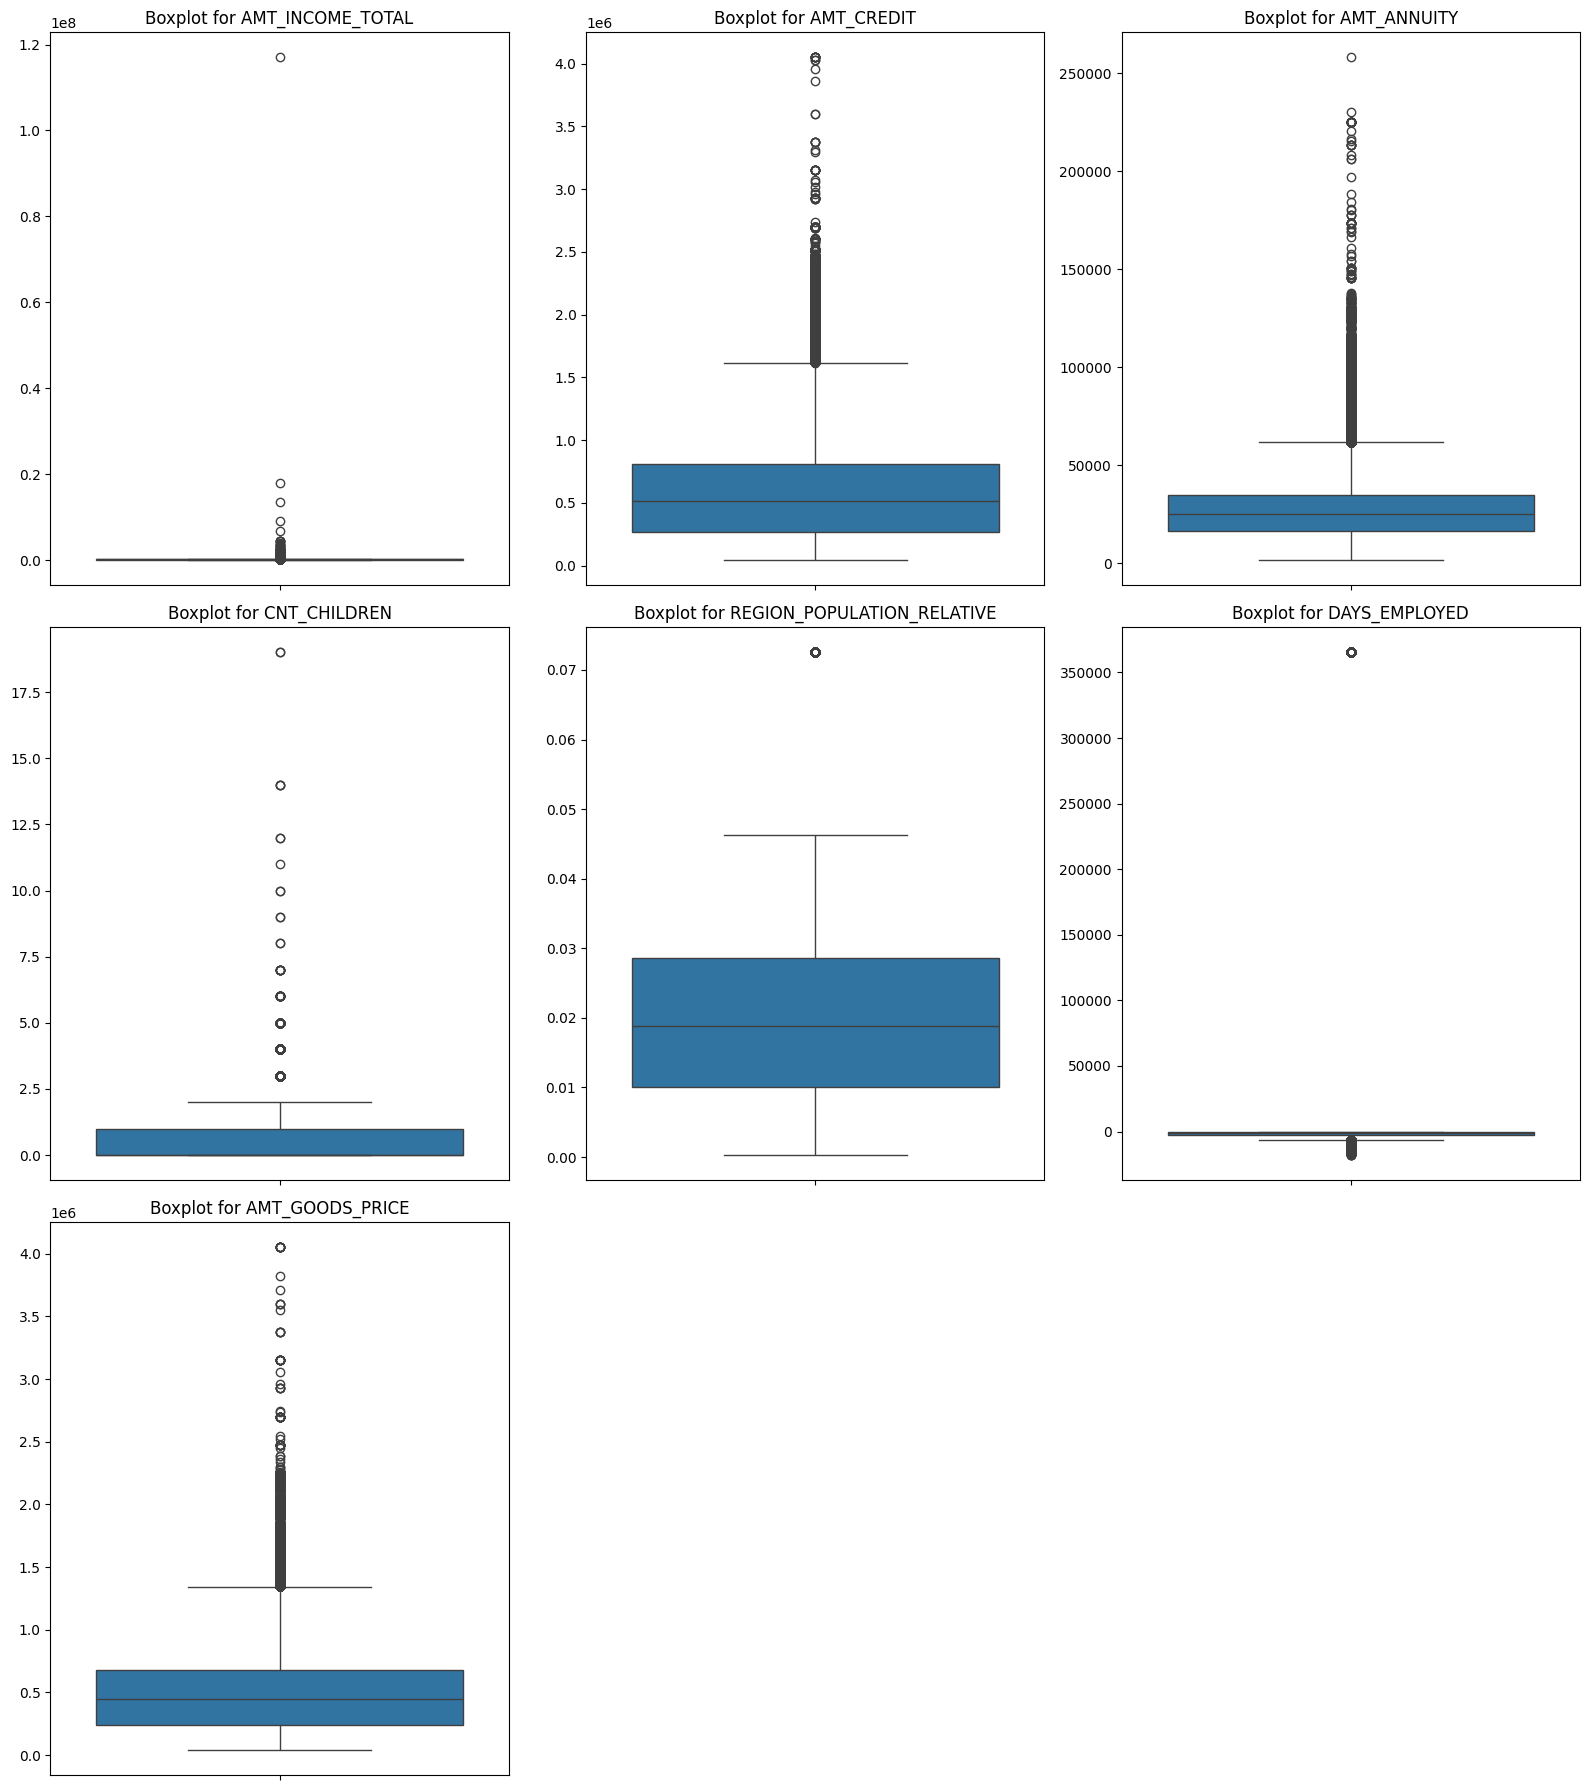

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_columns_app_train = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'CNT_CHILDREN',
    'REGION_POPULATION_RELATIVE',
    'DAYS_EMPLOYED',
    'AMT_GOODS_PRICE'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(outlier_columns_app_train):
    sns.boxplot(y=df_application_train[col], ax=axes[i])
    axes[i].set_title(f'Boxplot for {col}')
    axes[i].set_ylabel('')

for j in range(len(outlier_columns_app_train), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [34]:
upper_bound_children_cap = df_application_train['CNT_CHILDREN'].quantile(0.999)
df_application_train['CNT_CHILDREN'] = df_application_train['CNT_CHILDREN'].clip(upper=upper_bound_children_cap)
print(f"'CNT_CHILDREN' has been capped at the 99.9th percentile: {int(upper_bound_children_cap)}")
print(f"New maximum for 'CNT_CHILDREN': {int(df_application_train['CNT_CHILDREN'].max())}")
print()

upper_bound_income_cap = df_application_train['AMT_INCOME_TOTAL'].quantile(0.999)
df_application_train['AMT_INCOME_TOTAL'] = df_application_train['AMT_INCOME_TOTAL'].clip(upper=upper_bound_income_cap)
print(f"'AMT_INCOME_TOTAL' has been capped at the 99.9th percentile: {int(upper_bound_income_cap)}")
print(f"New maximum for 'AMT_INCOME_TOTAL': {int(df_application_train['AMT_INCOME_TOTAL'].max())}")

'CNT_CHILDREN' has been capped at the 99.9th percentile: 4
New maximum for 'CNT_CHILDREN': 4

'AMT_INCOME_TOTAL' has been capped at the 99.9th percentile: 900000
New maximum for 'AMT_INCOME_TOTAL': 900000


Dodatna analiza DAYS_EMPLOYED stupca je potrebna:

In [35]:
import numpy as np

print("Original descriptive statistics for DAYS_EMPLOYED (before transformation):")
display(df_application_train['DAYS_EMPLOYED'].describe())

df_application_train['UNEMPLOYED_RETIRED'] = (df_application_train['DAYS_EMPLOYED'] == 365243).astype(int)
print("\nCreated 'UNEMPLOYED_RETIRED' feature: 1 if DAYS_EMPLOYED was 365243, 0 otherwise.")
print(f"Number of 'UNEMPLOYED_RETIRED' individuals: {df_application_train['UNEMPLOYED_RETIRED'].sum()}")

df_application_train.loc[df_application_train['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = 0
print("Set DAYS_EMPLOYED to 0 for 'UNEMPLOYED_RETIRED' individuals.")

df_application_train['DAYS_EMPLOYED'] = df_application_train['DAYS_EMPLOYED'].abs()
print("Converted remaining DAYS_EMPLOYED values to absolute (positive) days.")

print("\nDescriptive statistics for DAYS_EMPLOYED (after transformation and handling sentinel value):")
display(df_application_train['DAYS_EMPLOYED'].describe())

print("\nValue counts for DAYS_EMPLOYED (first 10 values, sorted ascending, after transformation):")
display(df_application_train['DAYS_EMPLOYED'].value_counts(dropna=False).sort_index().head(10))

print("\nValue counts for DAYS_EMPLOYED around 0 (after transformation):")
display(df_application_train[ (df_application_train['DAYS_EMPLOYED'] >= 0) & (df_application_train['DAYS_EMPLOYED'] <= 1) ]['DAYS_EMPLOYED'].value_counts(dropna=False).sort_index())

print("\nMaximum value of DAYS_EMPLOYED (after handling):")
print(df_application_train['DAYS_EMPLOYED'].max())

print("\nMinimum value of DAYS_EMPLOYED (after handling):")
print(df_application_train['DAYS_EMPLOYED'].min())

Original descriptive statistics for DAYS_EMPLOYED (before transformation):


,DAYS_EMPLOYED
count,307511.000000
mean,63815.045904
std,141275.766519
min,-17912.000000
25%,-2760.000000
50%,-1213.000000
75%,-289.000000
max,365243.000000



Created 'UNEMPLOYED_RETIRED' feature: 1 if DAYS_EMPLOYED was 365243, 0 otherwise.
Number of 'UNEMPLOYED_RETIRED' individuals: 55374
Set DAYS_EMPLOYED to 0 for 'UNEMPLOYED_RETIRED' individuals.
Converted remaining DAYS_EMPLOYED values to absolute (positive) days.

Descriptive statistics for DAYS_EMPLOYED (after transformation and handling sentinel value):


,DAYS_EMPLOYED
count,307511.000000
mean,1954.848123
std,2307.068896
min,0.000000
25%,289.000000
50%,1213.000000
75%,2760.000000
max,17912.000000



Value counts for DAYS_EMPLOYED (first 10 values, sorted ascending, after transformation):


,count
DAYS_EMPLOYED,
0,55376
1,1
2,2
3,3
4,4
5,1
6,2
7,1
8,2



Value counts for DAYS_EMPLOYED around 0 (after transformation):


,count
DAYS_EMPLOYED,
0,55376
1,1



Maximum value of DAYS_EMPLOYED (after handling):
17912

Minimum value of DAYS_EMPLOYED (after handling):
0


Boxplot popravljene značajke

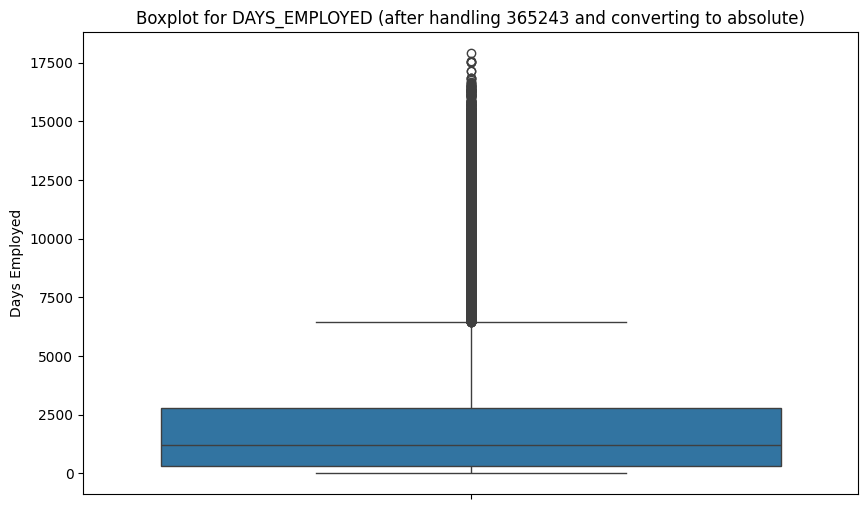

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y=df_application_train['DAYS_EMPLOYED'])
plt.title('Boxplot for DAYS_EMPLOYED (after handling 365243 and converting to absolute)')
plt.ylabel('Days Employed')
plt.show()

# 7.2. Bureau

In [37]:
import numpy as np

numerical_cols_bureau = df_bureau.select_dtypes(include=np.number).columns.tolist()

print(f"Checking for outliers in numerical features of df_bureau (using IQR method):\n")

outliers_found_bureau = False

for col in numerical_cols_bureau:
    Q1 = df_bureau[col].quantile(0.25)
    Q3 = df_bureau[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_bureau[(df_bureau[col] < lower_bound) | (df_bureau[col] > upper_bound)]

    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers found.")
        outliers_found_bureau = True

if not outliers_found_bureau:
    print("No outliers found in numerical columns of df_bureau using the IQR method.")

Checking for outliers in numerical features of df_bureau (using IQR method):

Column 'CREDIT_DAY_OVERDUE': 4217 outliers found.
Column 'DAYS_CREDIT_ENDDATE': 80891 outliers found.
Column 'AMT_CREDIT_MAX_OVERDUE': 121290 outliers found.
Column 'CNT_CREDIT_PROLONG': 9114 outliers found.
Column 'AMT_CREDIT_SUM': 187998 outliers found.
Column 'AMT_CREDIT_SUM_DEBT': 426105 outliers found.
Column 'AMT_CREDIT_SUM_LIMIT': 74506 outliers found.
Column 'AMT_CREDIT_SUM_OVERDUE': 4158 outliers found.
Column 'DAYS_CREDIT_UPDATE': 63755 outliers found.
Column 'AMT_ANNUITY': 232722 outliers found.


Od 14 numeričkih značajku u bureau datasetu čak ih 10 ima outliere.

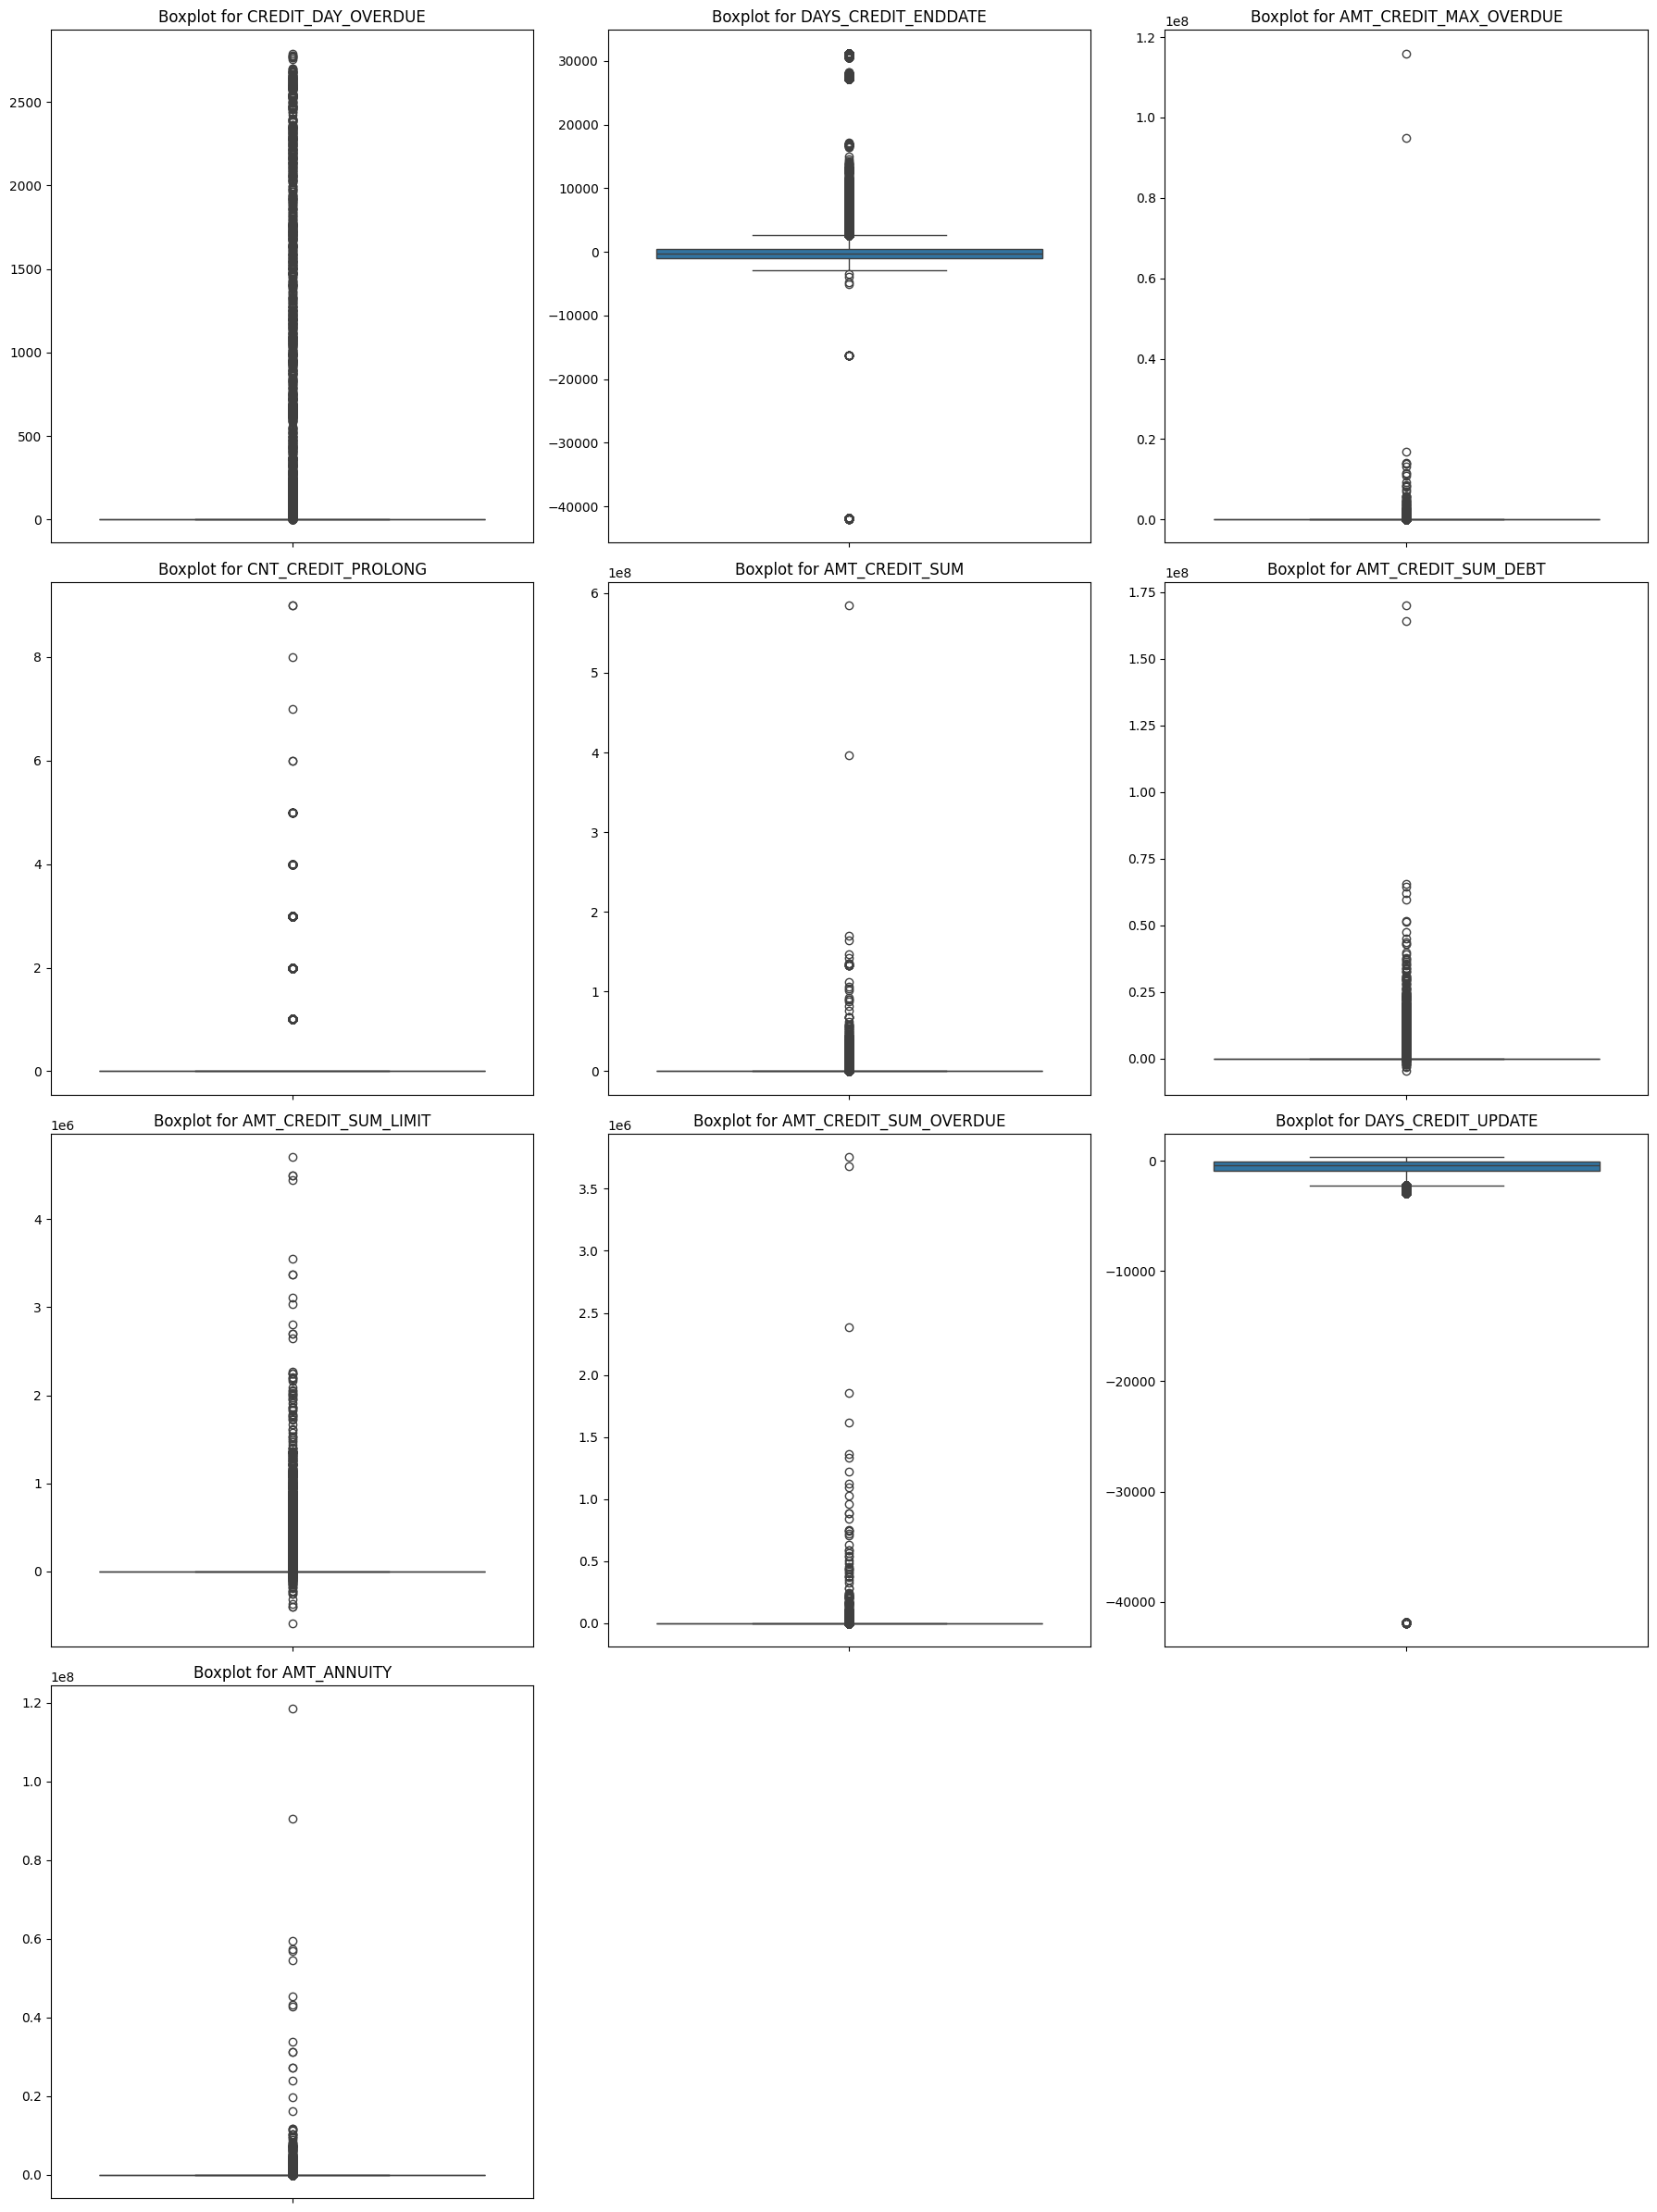

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_columns_bureau = [
    'CREDIT_DAY_OVERDUE',
    'DAYS_CREDIT_ENDDATE',
    'AMT_CREDIT_MAX_OVERDUE',
    'CNT_CREDIT_PROLONG',
    'AMT_CREDIT_SUM',
    'AMT_CREDIT_SUM_DEBT',
    'AMT_CREDIT_SUM_LIMIT',
    'AMT_CREDIT_SUM_OVERDUE',
    'DAYS_CREDIT_UPDATE',
    'AMT_ANNUITY'
]

fig, axes = plt.subplots(4, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(outlier_columns_bureau):
    sns.boxplot(y=df_bureau[col], ax=axes[i])
    axes[i].set_title(f'Boxplot for {col}')
    axes[i].set_ylabel('')

for j in range(len(outlier_columns_bureau), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Ekstremna stršila iz AMT_CREDIT_MAX_OVERDUE ograničena su na 99.9om percentilu kao kompromis između izbacivanja i zadržavanja tih vrijednosti.

In [39]:
upper_bound_credit_max_overdue_cap = df_bureau['AMT_CREDIT_MAX_OVERDUE'].quantile(0.999)
df_bureau['AMT_CREDIT_MAX_OVERDUE'] = df_bureau['AMT_CREDIT_MAX_OVERDUE'].clip(upper=upper_bound_credit_max_overdue_cap)
print(f"'AMT_CREDIT_MAX_OVERDUE' has been capped at the 99.9th percentile: {upper_bound_credit_max_overdue_cap}")
print(f"New maximum for 'AMT_CREDIT_MAX_OVERDUE': {df_bureau['AMT_CREDIT_MAX_OVERDUE'].max()}")

'AMT_CREDIT_MAX_OVERDUE' has been capped at the 99.9th percentile: 90537.52050000534
New maximum for 'AMT_CREDIT_MAX_OVERDUE': 90537.52050000534


Ekstremna stršila iz AMT_CREDIT_SUM, AMT_CREDIT_SUM_DEBT, AMT_CREDIT_SUM_LIMIT, AMT_CREDIT_SUM_OVERDUE ograničena su na 99.9om percentilu kao kompromis između izbacivanja i zadržavanja tih vrijednosti.

In [40]:
upper_bound_credit_sum_cap = df_bureau['AMT_CREDIT_SUM'].quantile(0.999)
df_bureau['AMT_CREDIT_SUM'] = df_bureau['AMT_CREDIT_SUM'].clip(upper=upper_bound_credit_sum_cap)
print(f"'AMT_CREDIT_SUM' has been capped at the 99.9th percentile: {upper_bound_credit_sum_cap}")
print(f"New maximum for 'AMT_CREDIT_SUM': {df_bureau['AMT_CREDIT_SUM'].max()}")

upper_bound_credit_sum_debt_cap = df_bureau['AMT_CREDIT_SUM_DEBT'].quantile(0.999)
df_bureau['AMT_CREDIT_SUM_DEBT'] = df_bureau['AMT_CREDIT_SUM_DEBT'].clip(upper=upper_bound_credit_sum_debt_cap)
print(f"\n'AMT_CREDIT_SUM_DEBT' has been capped at the 99.9th percentile: {upper_bound_credit_sum_debt_cap}")
print(f"New maximum for 'AMT_CREDIT_SUM_DEBT': {df_bureau['AMT_CREDIT_SUM_DEBT'].max()}")

upper_bound_credit_sum_limit_cap = df_bureau['AMT_CREDIT_SUM_LIMIT'].quantile(0.999)
df_bureau['AMT_CREDIT_SUM_LIMIT'] = df_bureau['AMT_CREDIT_SUM_LIMIT'].clip(upper=upper_bound_credit_sum_limit_cap)
print(f"\n'AMT_CREDIT_SUM_LIMIT' has been capped at the 99.9th percentile: {upper_bound_credit_sum_limit_cap}")
print(f"New maximum for 'AMT_CREDIT_SUM_LIMIT': {df_bureau['AMT_CREDIT_SUM_LIMIT'].max()}")

upper_bound_credit_sum_overdue_cap = df_bureau['AMT_CREDIT_SUM_OVERDUE'].quantile(0.999)
df_bureau['AMT_CREDIT_SUM_OVERDUE'] = df_bureau['AMT_CREDIT_SUM_OVERDUE'].clip(upper=upper_bound_credit_sum_overdue_cap)
print(f"\n'AMT_CREDIT_SUM_OVERDUE' has been capped at the 99.9th percentile: {upper_bound_credit_sum_overdue_cap}")
print(f"New maximum for 'AMT_CREDIT_SUM_OVERDUE': {df_bureau['AMT_CREDIT_SUM_OVERDUE'].max()}")

'AMT_CREDIT_SUM' has been capped at the 99.9th percentile: 11020992.493500078
New maximum for 'AMT_CREDIT_SUM': 11020992.493500078

'AMT_CREDIT_SUM_DEBT' has been capped at the 99.9th percentile: 8279416.881000109
New maximum for 'AMT_CREDIT_SUM_DEBT': 8279416.881000109

'AMT_CREDIT_SUM_LIMIT' has been capped at the 99.9th percentile: 468000.0
New maximum for 'AMT_CREDIT_SUM_LIMIT': 468000.0

'AMT_CREDIT_SUM_OVERDUE' has been capped at the 99.9th percentile: 450.0
New maximum for 'AMT_CREDIT_SUM_OVERDUE': 450.0


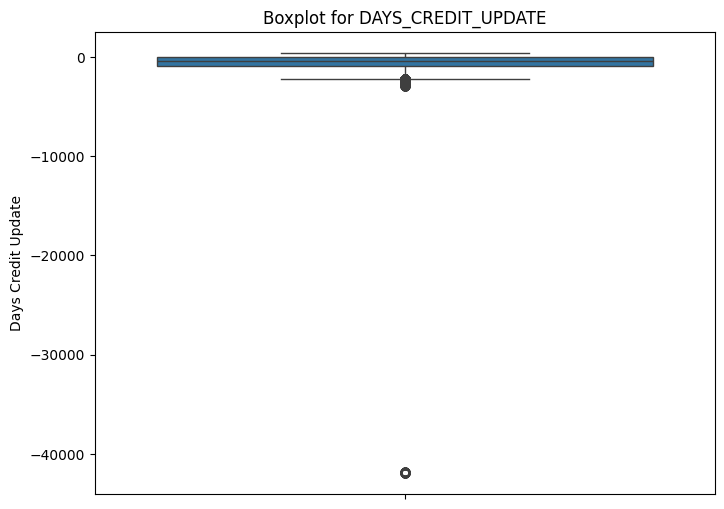

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_bureau['DAYS_CREDIT_UPDATE'])
plt.title('Boxplot for DAYS_CREDIT_UPDATE')
plt.ylabel('Days Credit Update')
plt.show()

Ograničavaju se vrijednosti na 0.1om i 99.9om percentilu, negativne vrijednosti samo predstavljaju prošlost.

In [42]:
lower_bound_days_credit_update_cap = df_bureau['DAYS_CREDIT_UPDATE'].quantile(0.001)
upper_bound_days_credit_update_cap = df_bureau['DAYS_CREDIT_UPDATE'].quantile(0.999)
df_bureau['DAYS_CREDIT_UPDATE'] = df_bureau['DAYS_CREDIT_UPDATE'].clip(lower=lower_bound_days_credit_update_cap, upper=upper_bound_days_credit_update_cap)
print(f"'DAYS_CREDIT_UPDATE' has been capped at the 0.1th percentile: {lower_bound_days_credit_update_cap} and 99.9th percentile: {upper_bound_days_credit_update_cap}")
print(f"New minimum for 'DAYS_CREDIT_UPDATE': {df_bureau['DAYS_CREDIT_UPDATE'].min()}")
print(f"New maximum for 'DAYS_CREDIT_UPDATE': {df_bureau['DAYS_CREDIT_UPDATE'].max()}")

'DAYS_CREDIT_UPDATE' has been capped at the 0.1th percentile: -2742.0 and 99.9th percentile: -1.0
New minimum for 'DAYS_CREDIT_UPDATE': -2742
New maximum for 'DAYS_CREDIT_UPDATE': -1


Ograničava se par ekstremnih stršila iz AMT_ANNUITY na 99.9om percentilu.

In [43]:
upper_bound_annuity_cap = df_bureau['AMT_ANNUITY'].quantile(0.999)
df_bureau['AMT_ANNUITY'] = df_bureau['AMT_ANNUITY'].clip(upper=upper_bound_annuity_cap)
print(f"'AMT_ANNUITY' has been capped at the 99.9th percentile: {upper_bound_annuity_cap}")
print(f"New maximum for 'AMT_ANNUITY': {df_bureau['AMT_ANNUITY'].max()}")

'AMT_ANNUITY' has been capped at the 99.9th percentile: 311179.5
New maximum for 'AMT_ANNUITY': 311179.5


# 7.3. Previous_application

In [44]:
import numpy as np

numerical_cols_prev_app = df_previous_application.select_dtypes(include=np.number).columns.tolist()

print(f"Checking for outliers in numerical features of df_previous_application (using IQR method):\n")

outliers_found_prev_app = False

for col in numerical_cols_prev_app:
    Q1 = df_previous_application[col].quantile(0.25)
    Q3 = df_previous_application[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_previous_application[(df_previous_application[col] < lower_bound) | (df_previous_application[col] > upper_bound)]

    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers found.")
        outliers_found_prev_app = True

if not outliers_found_prev_app:
    print("No outliers found in numerical columns of df_previous_application using the IQR method.")


Checking for outliers in numerical features of df_previous_application (using IQR method):

Column 'AMT_APPLICATION': 208019 outliers found.
Column 'AMT_CREDIT': 179989 outliers found.


Postoje samo dvije značajke sa stršilima:

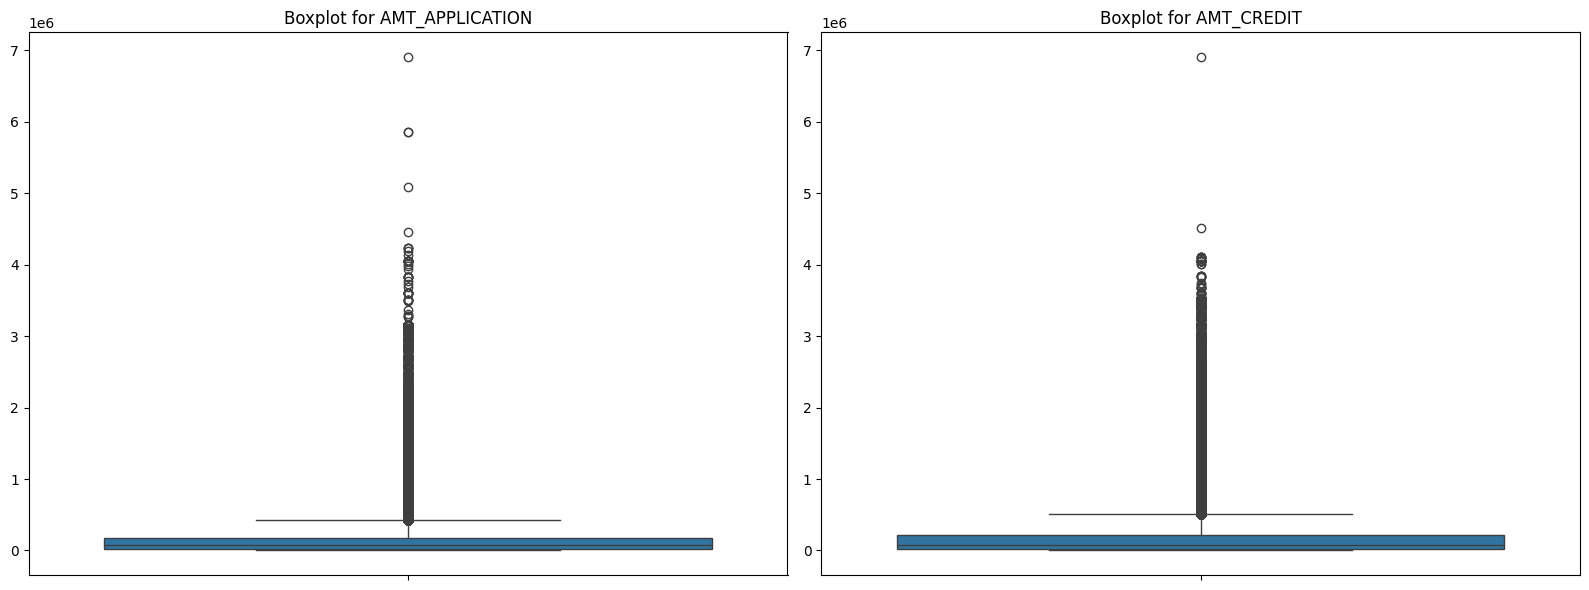

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_columns_prev_app_viz = ['AMT_APPLICATION', 'AMT_CREDIT']

num_plots = len(outlier_columns_prev_app_viz)
num_rows = (num_plots + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(16, 6 * num_rows))
axes = axes.flatten()

for i, col in enumerate(outlier_columns_prev_app_viz):
    sns.boxplot(y=df_previous_application[col], ax=axes[i])
    axes[i].set_title(f'Boxplot for {col}')
    axes[i].set_ylabel('')

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Sva su stršila relativno smislena nema potrebe za izmjenom.

# 7.4. Installments_payments

In [46]:
import numpy as np

numerical_cols_installments = df_installments_payments.select_dtypes(include=np.number).columns.tolist()

print(f"Checking for outliers in numerical features of df_installments_payments (using IQR method):\n")

outliers_found_installments = False

for col in numerical_cols_installments:
    Q1 = df_installments_payments[col].quantile(0.25)
    Q3 = df_installments_payments[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_installments_payments[(df_installments_payments[col] < lower_bound) | (df_installments_payments[col] > upper_bound)]

    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers found.")
        outliers_found_installments = True

if not outliers_found_installments:
    print("No outliers found in numerical columns of df_installments_payments using the IQR method.")


Checking for outliers in numerical features of df_installments_payments (using IQR method):

Column 'NUM_INSTALMENT_VERSION': 417616 outliers found.
Column 'NUM_INSTALMENT_NUMBER': 1886320 outliers found.
Column 'DAYS_ENTRY_PAYMENT': 1 outliers found.
Column 'AMT_INSTALMENT': 1120800 outliers found.
Column 'AMT_PAYMENT': 1130428 outliers found.


Postoji 5 značajki sa stršilima:

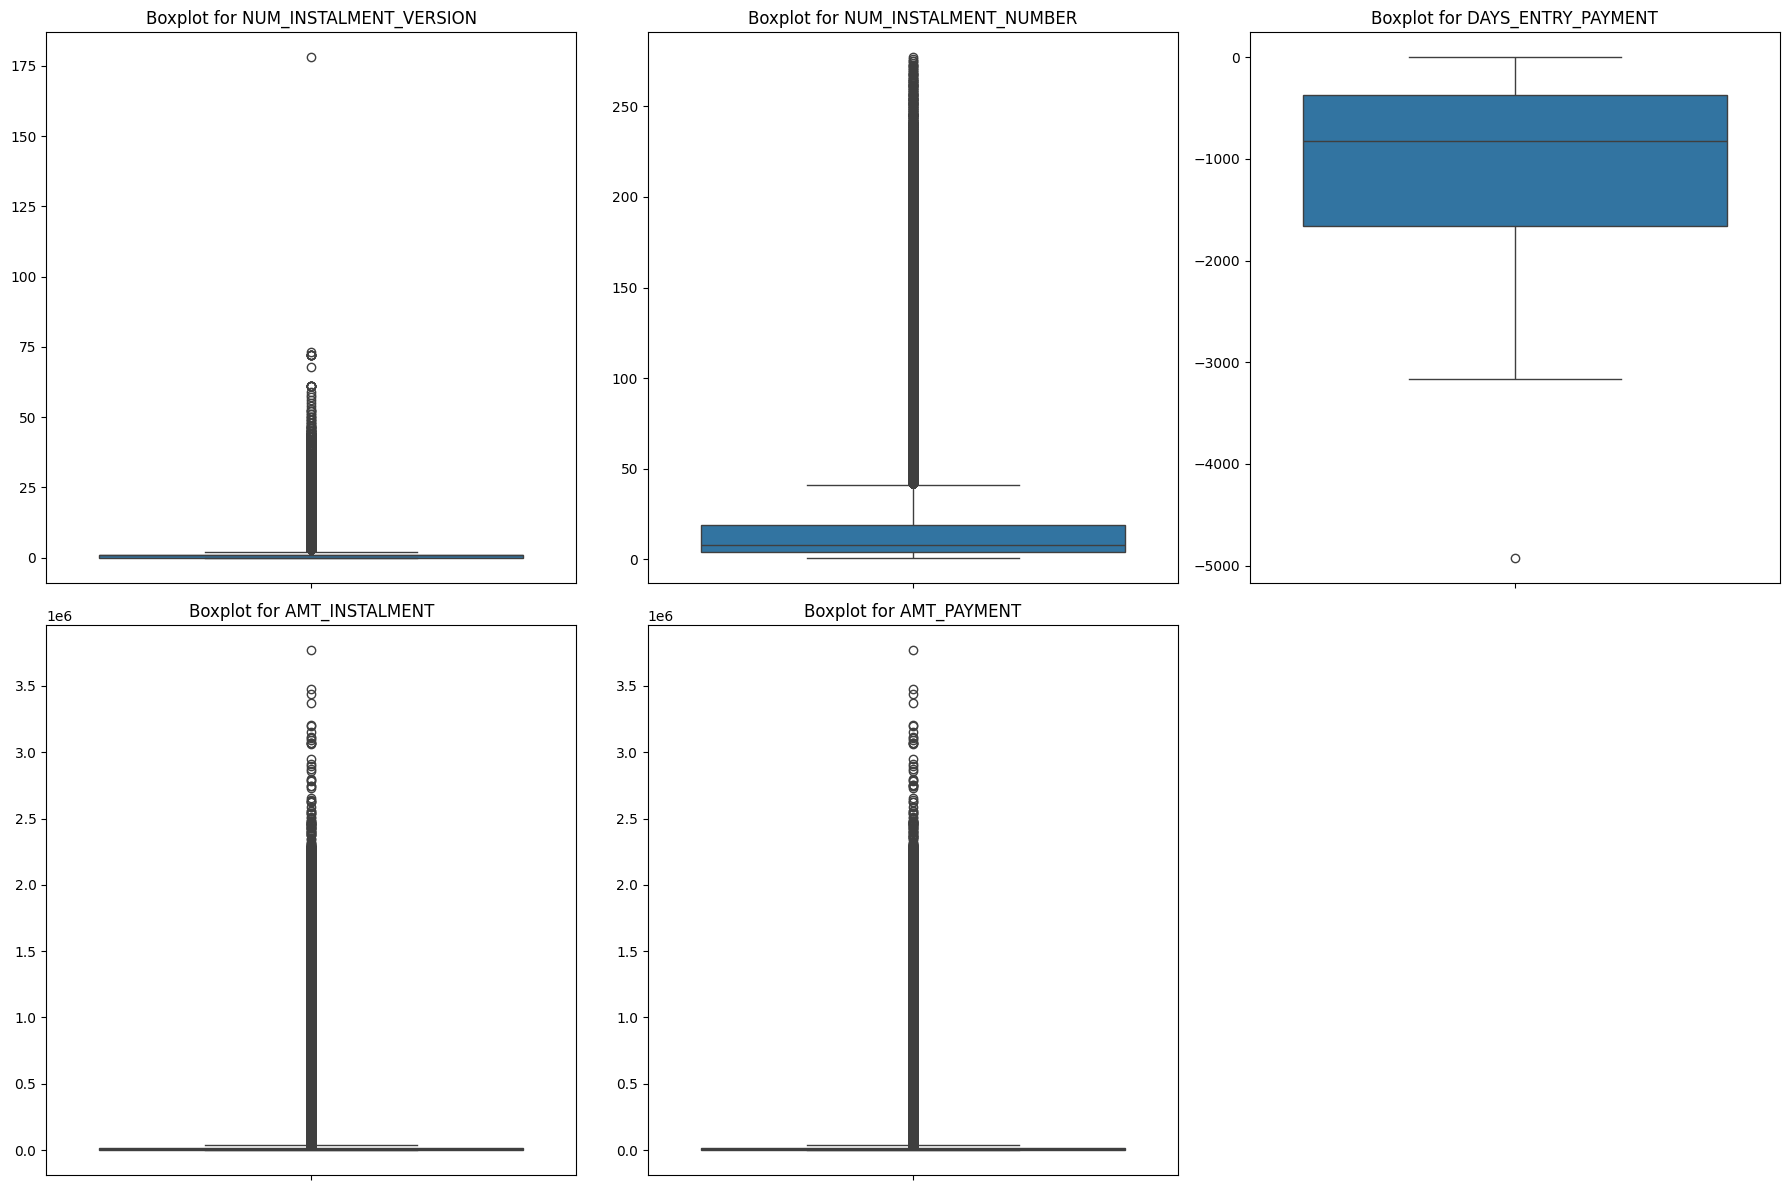

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_columns_installments_viz = [
    'NUM_INSTALMENT_VERSION',
    'NUM_INSTALMENT_NUMBER',
    'DAYS_ENTRY_PAYMENT',
    'AMT_INSTALMENT',
    'AMT_PAYMENT'
]

num_plots = len(outlier_columns_installments_viz)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 6 * num_rows))
axes = axes.flatten()

for i, col in enumerate(outlier_columns_installments_viz):
    sns.boxplot(y=df_installments_payments[col], ax=axes[i])
    axes[i].set_title(f'Boxplot for {col}')
    axes[i].set_ylabel('')

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Sva su stršila ili smislena ili su vrlo malobrojna npr. 1 ekstremno stršilo na skupu od 13.6M redaka...

# 8. Distribucija ciljne varijable

Distribution of TARGET variable:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


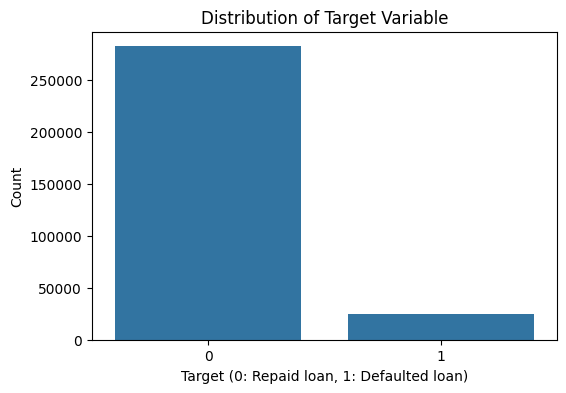

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

target_distribution = df_application_train['TARGET'].value_counts(normalize=True) * 100

print("Distribution of TARGET variable:")
print(target_distribution)

plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df_application_train)
plt.title('Distribution of Target Variable')
plt.xlabel('Target (0: Repaid loan, 1: Defaulted loan)')
plt.ylabel('Count')
plt.show()

91.93% redova u application_train su otplaćeni krediti, a 8.07% redova predstavlja klijente sa poteškoćama sa otplatom kredita. Ovo se naknadno mora uravnotežiti kako model ne bi disproporcionalno predviđao većinsku klasu isključivo radi točnosti.

# 9. Analiza prihoda klijenata i iznosa kredita

# 9.1. Analiza prihoda klijenata

--- Analiza prihoda klijenata (AMT_INCOME_TOTAL) ---

Deskriptivne statistike za 'AMT_INCOME_TOTAL':
count    307511.000000
mean     167771.350678
std       91928.892668
min       25650.000000
25%      112500.000000
50%      147150.000000
75%      202500.000000
max      900000.000000
Name: AMT_INCOME_TOTAL, dtype: float64


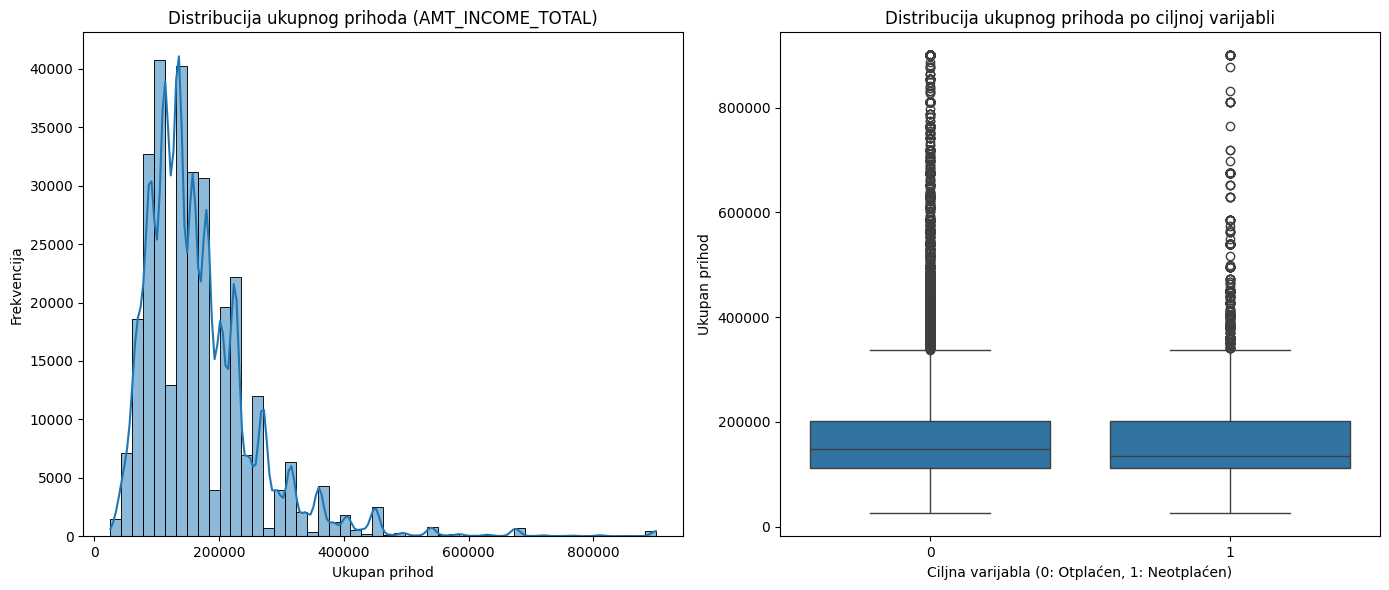


Prosječan 'AMT_INCOME_TOTAL' po TARGET varijabli:
TARGET
0    168399.403769
1    160619.615891
Name: AMT_INCOME_TOTAL, dtype: float64


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Analiza prihoda klijenata (AMT_INCOME_TOTAL) ---")

print("\nDeskriptivne statistike za 'AMT_INCOME_TOTAL':")
print(df_application_train['AMT_INCOME_TOTAL'].describe())

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_application_train['AMT_INCOME_TOTAL'], kde=True, bins=50)
plt.title('Distribucija ukupnog prihoda (AMT_INCOME_TOTAL)')
plt.xlabel('Ukupan prihod')
plt.ylabel('Frekvencija')

plt.subplot(1, 2, 2)
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df_application_train)
plt.title('Distribucija ukupnog prihoda po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Ukupan prihod')

plt.tight_layout()
plt.show()

print("\nProsječan 'AMT_INCOME_TOTAL' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['AMT_INCOME_TOTAL'].mean())


Od 307511 klijenata prosjek prihoda je 167 771, standardna devijacija je 91 928 što upućuje na veliku razliku među ljudima što se prihoda tiče. Što se distribucije ukupnog prihoda tiče histogram prikazuje unimodalnu distribuciju i blago desno iskrivljen graf. Boxplot dijagrami prikazuju da nema drastične razlike između klijenata koji otplaćuju i ne otplaćuju kredit.

# 9.2. Analiza iznosa kredita

--- Analiza iznosa kredita (AMT_CREDIT) ---

Deskriptivne statistike za 'AMT_CREDIT':
count    307511.00
mean     599026.00
std      402490.78
min       45000.00
25%      270000.00
50%      513531.00
75%      808650.00
max     4050000.00
Name: AMT_CREDIT, dtype: float64


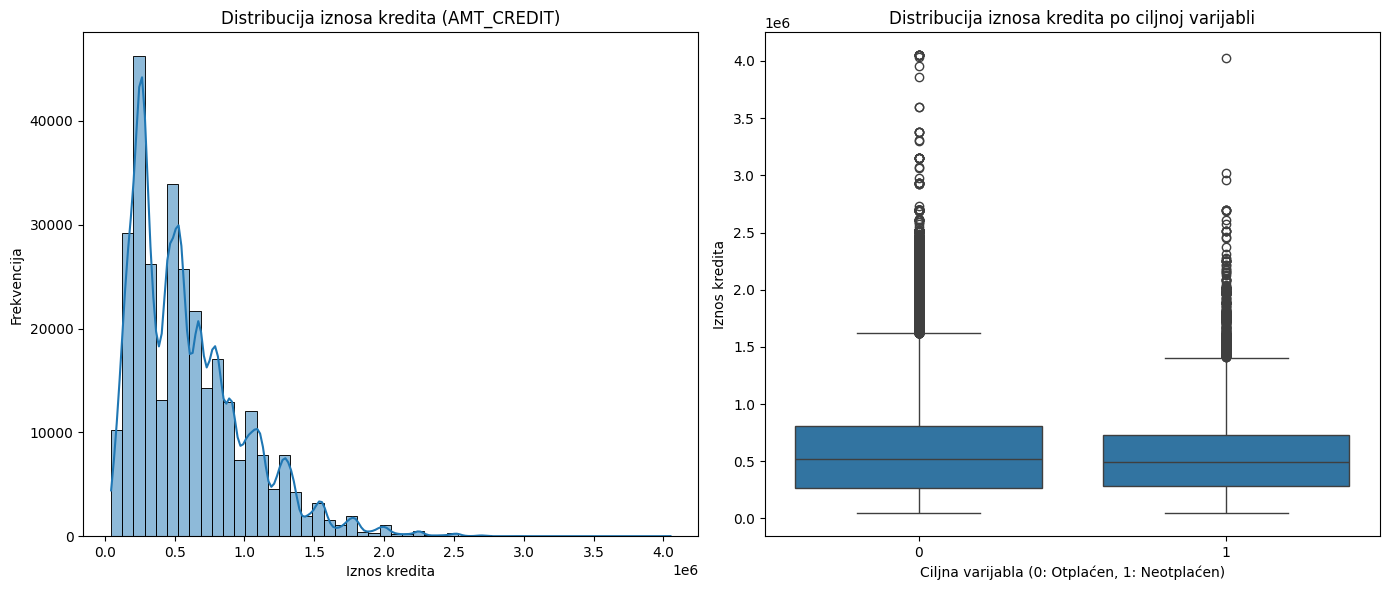


Prosječan 'AMT_CREDIT' po TARGET varijabli:
TARGET
0   602648.28
1   557778.53
Name: AMT_CREDIT, dtype: float64


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("--- Analiza iznosa kredita (AMT_CREDIT) ---")

print("\nDeskriptivne statistike za 'AMT_CREDIT':")
print(df_application_train['AMT_CREDIT'].describe())

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_application_train['AMT_CREDIT'], kde=True, bins=50)
plt.title('Distribucija iznosa kredita (AMT_CREDIT)')
plt.xlabel('Iznos kredita')
plt.ylabel('Frekvencija')

plt.subplot(1, 2, 2)
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=df_application_train)
plt.title('Distribucija iznosa kredita po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Iznos kredita')

plt.tight_layout()
plt.show()

print("\nProsječan 'AMT_CREDIT' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['AMT_CREDIT'].mean())

Od 307511 klijenata prosjek kredita je 599 026, a standardna devijacija je 402 490 što upućuje na veliku razliku među kreditima, raspon je od 45 000 do 4 050 000. Distribucija iznosa kredita je unimodalna i desno iskrivljena, prosječna AMT_CREDIT je za otplaćene kredite 602 648, a za klijente koji su imali poteškoće s otplaćivanjem 557 778. Boxplot prikazuje da postoji određena razlika u distribuciji i stršilima među skupovima.

# 10. Analiza omjera kredita i prihoda

--- Analiza omjera kredita i prihoda (CREDIT_INCOME_RATIO) ---

Deskriptivne statistike za 'CREDIT_INCOME_RATIO':
count   307511.00
mean         3.96
std          2.69
min          0.08
25%          2.02
50%          3.27
75%          5.16
max         84.74
Name: CREDIT_INCOME_RATIO, dtype: float64


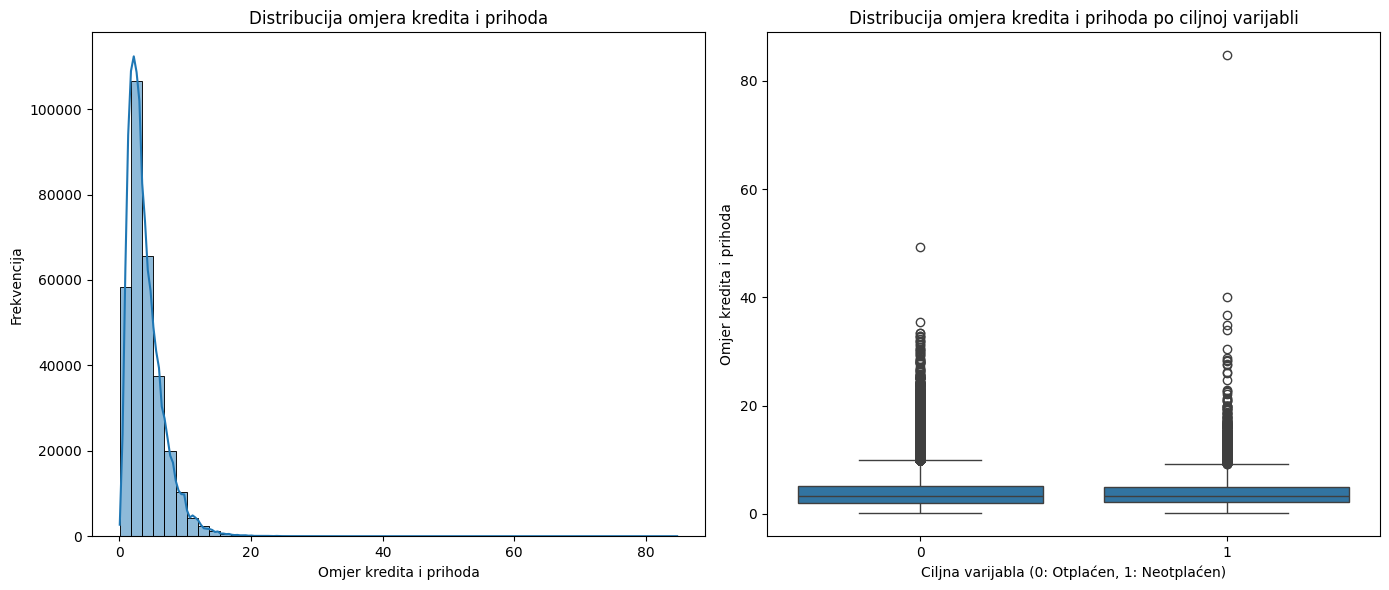


Prosječan 'CREDIT_INCOME_RATIO' po TARGET varijabli:
TARGET
0   3.96
1   3.89
Name: CREDIT_INCOME_RATIO, dtype: float64


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

df_application_train['CREDIT_INCOME_RATIO'] = df_application_train['AMT_CREDIT'] / df_application_train['AMT_INCOME_TOTAL']

print("--- Analiza omjera kredita i prihoda (CREDIT_INCOME_RATIO) ---")

print("\nDeskriptivne statistike za 'CREDIT_INCOME_RATIO':")
print(df_application_train['CREDIT_INCOME_RATIO'].describe())

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_application_train['CREDIT_INCOME_RATIO'], kde=True, bins=50)
plt.title('Distribucija omjera kredita i prihoda')
plt.xlabel('Omjer kredita i prihoda')
plt.ylabel('Frekvencija')

plt.subplot(1, 2, 2)
sns.boxplot(x='TARGET', y='CREDIT_INCOME_RATIO', data=df_application_train)
plt.title('Distribucija omjera kredita i prihoda po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Omjer kredita i prihoda')

plt.tight_layout()
plt.show()

print("\nProsječan 'CREDIT_INCOME_RATIO' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['CREDIT_INCOME_RATIO'].mean())

Ova značajka originalno nije bila prisutna, stoga je kreirana formulom CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL.
Prosječan omjer je 3.96, standardna devijacija omjera je 2.69, raspon od 0.08 do 84.74 što znači da neki uplate kredit znatno iznad svojeg dosadašnjeg prihoda, a neki znatno ispod svojeg dosadašnjeg prihoda. Distribucija je unimodalna i blago desno iskrivljena,  boxplotovi ne pokazuju značajnu razliku među klasama


# 11. Analiza obrazovanja, obiteljskog statusa i tipa ugovora,

# 11.1. Analiza obrazovanja

# 11.1. Analiza obrazovanja (NAME_EDUCATION_TYPE)

Distribucija 'NAME_EDUCATION_TYPE_Original':
NAME_EDUCATION_TYPE_Original
Secondary / secondary special   71.02
Higher education                24.34
Incomplete higher                3.34
Lower secondary                  1.24
Academic degree                  0.05
Name: proportion, dtype: float64


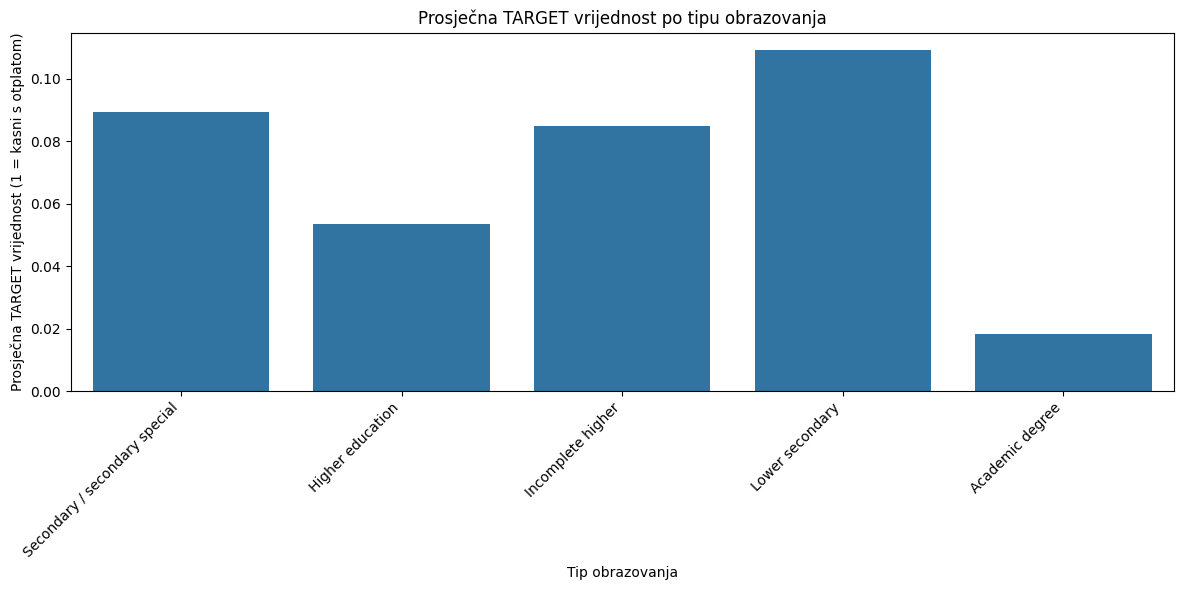


Prosječna TARGET vrijednost po 'NAME_EDUCATION_TYPE_Original':
NAME_EDUCATION_TYPE_Original
Lower secondary                 0.11
Secondary / secondary special   0.09
Incomplete higher               0.08
Higher education                0.05
Academic degree                 0.02
Name: TARGET, dtype: float64


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("# 11.1. Analiza obrazovanja (NAME_EDUCATION_TYPE)")

education_cols = [col for col in df_application_train.columns if col.startswith('NAME_EDUCATION_TYPE_')]
df_education_analysis = df_application_train[education_cols + ['TARGET']].copy()
df_education_analysis['NAME_EDUCATION_TYPE_Original'] = df_education_analysis[education_cols].idxmax(axis=1).str.replace('NAME_EDUCATION_TYPE_', '')

print("\nDistribucija 'NAME_EDUCATION_TYPE_Original':")
education_distribution = df_education_analysis['NAME_EDUCATION_TYPE_Original'].value_counts(normalize=True) * 100
print(education_distribution)


plt.figure(figsize=(12, 6))
sns.barplot(x='NAME_EDUCATION_TYPE_Original', y='TARGET', data=df_education_analysis, errorbar=None, order=education_distribution.index)
plt.title('Prosječna TARGET vrijednost po tipu obrazovanja')
plt.xlabel('Tip obrazovanja')
plt.ylabel('Prosječna TARGET vrijednost (1 = kasni s otplatom)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nProsječna TARGET vrijednost po 'NAME_EDUCATION_TYPE_Original':")
print(df_education_analysis.groupby('NAME_EDUCATION_TYPE_Original')['TARGET'].mean().sort_values(ascending=False))

Zastupljenosti obrazovanja su:

1.	Secondary / secondary special (71.02%)

2.	Higher education (24.34%)

3.	Incomplete higher (3.34%)

4.	Lower secondary (1.24%)

5.	Academic degree (0.05%),

A prosječne TARGET vrijednosti po tipu obrazovanja

1. Lower secondary                 0.11

2. Secondary / secondary special   0.09

3. Incomplete higher               0.08

4. Higher education                0.05

5. Academic degree                 0.02

što znači da određene vrste obrazovanja imaju veću šansu otplatiti kredit.

# 11.2. Analiza obiteljskog statusa

# 11.2. Analiza obiteljskog statusa (NAME_FAMILY_STATUS)

Distribucija 'NAME_FAMILY_STATUS_Original':
NAME_FAMILY_STATUS_Original
Married                63.88
Single / not married   14.78
Civil marriage          9.68
Separated               6.43
Widow                   5.23
Name: proportion, dtype: float64


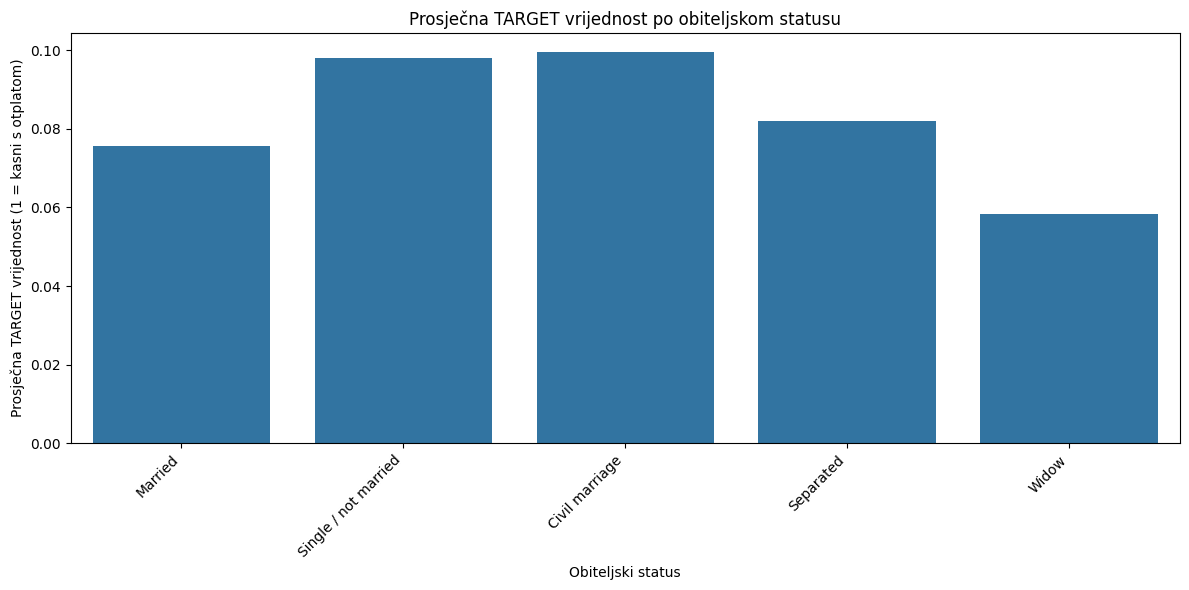


Prosječna TARGET vrijednost po 'NAME_FAMILY_STATUS_Original':
NAME_FAMILY_STATUS_Original
Civil marriage         0.10
Single / not married   0.10
Separated              0.08
Married                0.08
Widow                  0.06
Name: TARGET, dtype: float64


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("# 11.2. Analiza obiteljskog statusa (NAME_FAMILY_STATUS)")

family_status_analysis = df_application_train[['NAME_FAMILY_STATUS_Civil marriage', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow', 'TARGET']].copy()

family_status_cols = [col for col in family_status_analysis.columns if col.startswith('NAME_FAMILY_STATUS_')]
family_status_analysis['NAME_FAMILY_STATUS_Original'] = family_status_analysis[family_status_cols].idxmax(axis=1).str.replace('NAME_FAMILY_STATUS_', '')

print("\nDistribucija 'NAME_FAMILY_STATUS_Original':")
family_status_distribution = family_status_analysis['NAME_FAMILY_STATUS_Original'].value_counts(normalize=True) * 100
print(family_status_distribution)

plt.figure(figsize=(12, 6))
sns.barplot(x='NAME_FAMILY_STATUS_Original', y='TARGET', data=family_status_analysis, errorbar=None, order=family_status_distribution.index)
plt.title('Prosječna TARGET vrijednost po obiteljskom statusu')
plt.xlabel('Obiteljski status')
plt.ylabel('Prosječna TARGET vrijednost (1 = kasni s otplatom)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nProsječna TARGET vrijednost po 'NAME_FAMILY_STATUS_Original':")
print(family_status_analysis.groupby('NAME_FAMILY_STATUS_Original')['TARGET'].mean().sort_values(ascending=False))

Distribucija obiteljskog statusa:

1.	Married (63.88%)
2.	Single / not married (14.78%)
3.	Civil marriage (9.68%)
4.	Separated (6.43%)
5.	Widow (5.23%),

a prosječne TARGET vrijednosti po obiteljskom statusu:

1. Civil marriage         (0.10)
2. Single / not married   (0.10)
3. Separated              (0.08)
4. Married                (0.08)
5. Widow                  (0.06)

# 11.3. Analiza tipa ugovora

# 11.3. Analiza tipa ugovora (NAME_CONTRACT_TYPE)

Distribucija 'NAME_CONTRACT_TYPE_Original':
NAME_CONTRACT_TYPE_Original
Cash loans        90.48
Revolving loans    9.52
Name: proportion, dtype: float64


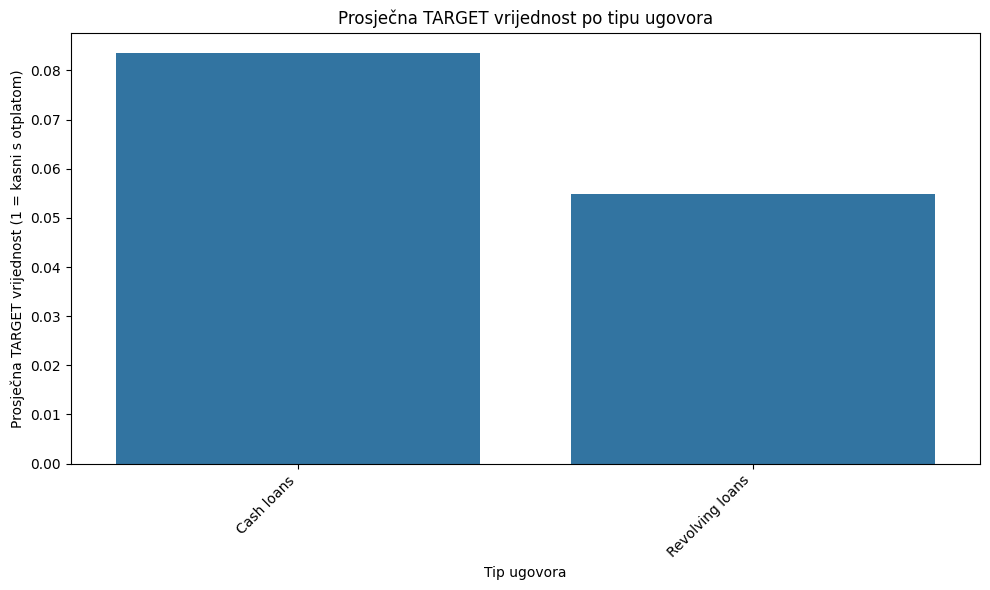


Prosječna TARGET vrijednost po 'NAME_CONTRACT_TYPE_Original':
NAME_CONTRACT_TYPE_Original
Cash loans        0.08
Revolving loans   0.05
Name: TARGET, dtype: float64


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("# 11.3. Analiza tipa ugovora (NAME_CONTRACT_TYPE)")

contract_type_cols = [col for col in df_application_train.columns if col.startswith('NAME_CONTRACT_TYPE_')]
df_contract_type_analysis = df_application_train[contract_type_cols + ['TARGET']].copy()
df_contract_type_analysis['NAME_CONTRACT_TYPE_Original'] = df_contract_type_analysis[contract_type_cols].idxmax(axis=1).str.replace('NAME_CONTRACT_TYPE_', '')

print("\nDistribucija 'NAME_CONTRACT_TYPE_Original':")
contract_type_distribution = df_contract_type_analysis['NAME_CONTRACT_TYPE_Original'].value_counts(normalize=True) * 100
print(contract_type_distribution)

plt.figure(figsize=(10, 6))
sns.barplot(x='NAME_CONTRACT_TYPE_Original', y='TARGET', data=df_contract_type_analysis, errorbar=None, order=contract_type_distribution.index)
plt.title('Prosječna TARGET vrijednost po tipu ugovora')
plt.xlabel('Tip ugovora')
plt.ylabel('Prosječna TARGET vrijednost (1 = kasni s otplatom)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nProsječna TARGET vrijednost po 'NAME_CONTRACT_TYPE_Original':")
print(df_contract_type_analysis.groupby('NAME_CONTRACT_TYPE_Original')['TARGET'].mean().sort_values(ascending=False))

Postoje dvije vrste ugovora u dataframeu, 'Cash loans' sa zastupljenošću od 90.48% i 'Revolving loans' sa zastupljenošću od 9.52% i ovisno o tipu ugovora TARGET vrijednosti izgledaju ovako:

1. Cash loans        (0.08)
2. Revolving loans   (0.05)

što znači da tip ugovora značajno utječe na problematičnost otplaćivanja istog.

# 12. Analiza korelacije numeričkih varijabli s ciljem

In [55]:
import pandas as pd

numerical_cols = df_application_train.select_dtypes(include=['number']).columns


if 'SK_ID_CURR' in numerical_cols:
    numerical_cols = numerical_cols.drop('SK_ID_CURR')

correlations = df_application_train[numerical_cols].corr()['TARGET']

correlations_sorted_by_abs = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

print("\nKorelacija numeričkih varijabli s 'TARGET' u df_application_train (sortirano po apsolutnoj vrijednosti):")
print(correlations_sorted_by_abs)


Korelacija numeričkih varijabli s 'TARGET' u df_application_train (sortirano po apsolutnoj vrijednosti):
TARGET                        1.00
DAYS_BIRTH                    0.08
DAYS_EMPLOYED                -0.05
UNEMPLOYED_RETIRED           -0.05
AMT_GOODS_PRICE              -0.04
REGION_POPULATION_RELATIVE   -0.04
AMT_CREDIT                   -0.03
AMT_INCOME_TOTAL             -0.02
FLAG_OWN_CAR                 -0.02
CNT_CHILDREN                  0.02
AMT_ANNUITY                  -0.01
CNT_FAM_MEMBERS               0.01
CREDIT_INCOME_RATIO          -0.01
FLAG_OWN_REALTY              -0.01
Name: TARGET, dtype: float64


# 13. Usporedba klijenata s TARGET = 0 i TARGET = 1

# 13.1. Analiza starosti klijenata (DAYS_BIRTH) po ciljnoj varijabli

# 13.1. Analiza starosti klijenata (DAYS_BIRTH) po ciljnoj varijabli


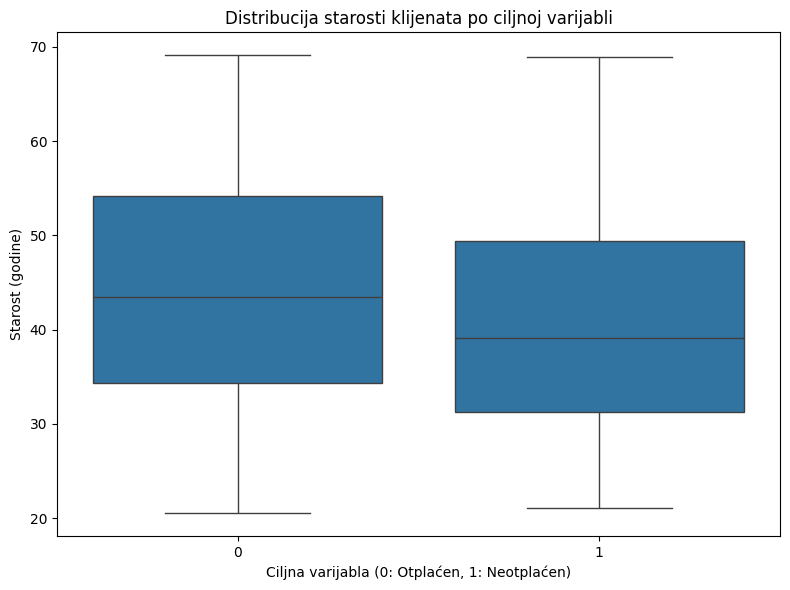


Prosječna 'AGE_YEARS' po TARGET varijabli:
TARGET
0   44.21
1   40.78
Name: AGE_YEARS, dtype: float64

Medijan 'AGE_YEARS' po TARGET varijabli:
TARGET
0   43.50
1   39.13
Name: AGE_YEARS, dtype: float64


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("# 13.1. Analiza starosti klijenata (DAYS_BIRTH) po ciljnoj varijabli")

df_application_train['AGE_YEARS'] = np.abs(df_application_train['DAYS_BIRTH']) / 365

plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='AGE_YEARS', data=df_application_train)
plt.title('Distribucija starosti klijenata po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Starost (godine)')
plt.tight_layout()
plt.show()

print("\nProsječna 'AGE_YEARS' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['AGE_YEARS'].mean())

print("\nMedijan 'AGE_YEARS' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['AGE_YEARS'].median())


### 13.2. Analiza trajanja zaposlenosti (DAYS_EMPLOYED) po ciljnoj varijabli

# 13.2. Analiza trajanja zaposlenosti (DAYS_EMPLOYED) po ciljnoj varijabli


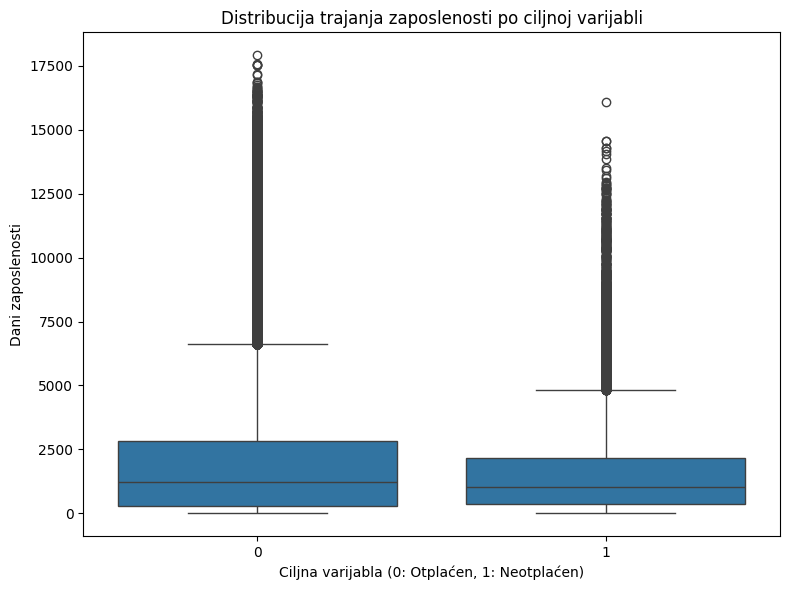


Prosječni 'DAYS_EMPLOYED' po TARGET varijabli:
TARGET
0   1986.33
1   1596.32
Name: DAYS_EMPLOYED, dtype: float64

Medijan 'DAYS_EMPLOYED' po TARGET varijabli:
TARGET
0   1235.00
1   1034.00
Name: DAYS_EMPLOYED, dtype: float64


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("# 13.2. Analiza trajanja zaposlenosti (DAYS_EMPLOYED) po ciljnoj varijabli")

plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='DAYS_EMPLOYED', data=df_application_train)
plt.title('Distribucija trajanja zaposlenosti po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Dani zaposlenosti')
plt.tight_layout()
plt.show()

print("\nProsječni 'DAYS_EMPLOYED' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['DAYS_EMPLOYED'].mean())

print("\nMedijan 'DAYS_EMPLOYED' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['DAYS_EMPLOYED'].median())

### 13.3. Analiza cijene proizvoda za kredit (AMT_GOODS_PRICE) po ciljnoj varijabli

# 13.3. Analiza cijene proizvoda za kredit (AMT_GOODS_PRICE) po ciljnoj varijabli


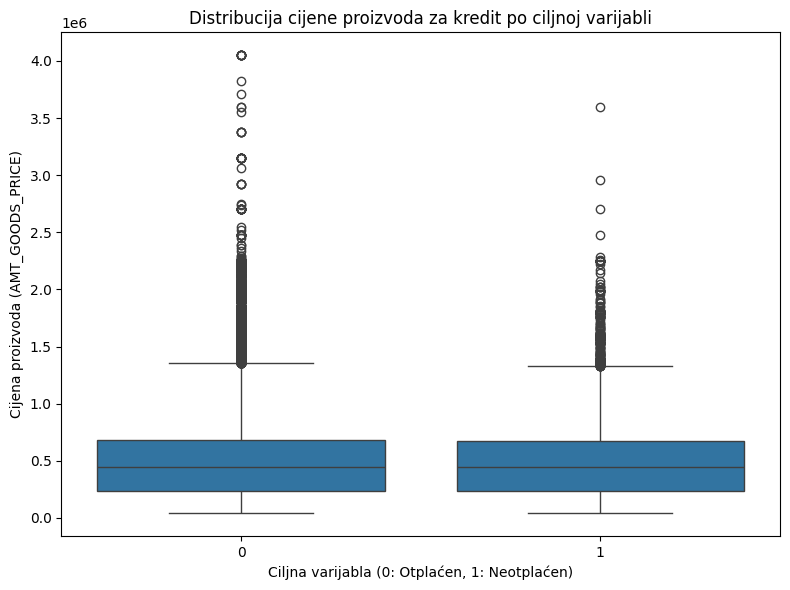


Prosječna 'AMT_GOODS_PRICE' po TARGET varijabli:
TARGET
0   542652.48
1   488939.44
Name: AMT_GOODS_PRICE, dtype: float64

Medijan 'AMT_GOODS_PRICE' po TARGET varijabli:
TARGET
0   450000.00
1   450000.00
Name: AMT_GOODS_PRICE, dtype: float64


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("# 13.3. Analiza cijene proizvoda za kredit (AMT_GOODS_PRICE) po ciljnoj varijabli")

plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='AMT_GOODS_PRICE', data=df_application_train)
plt.title('Distribucija cijene proizvoda za kredit po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Cijena proizvoda (AMT_GOODS_PRICE)')
plt.tight_layout()
plt.show()

print("\nProsječna 'AMT_GOODS_PRICE' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['AMT_GOODS_PRICE'].mean())

print("\nMedijan 'AMT_GOODS_PRICE' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['AMT_GOODS_PRICE'].median())

### 13.4. Analiza anuiteta (AMT_ANNUITY) po ciljnoj varijabli

# 13.4. Analiza anuiteta (AMT_ANNUITY) po ciljnoj varijabli


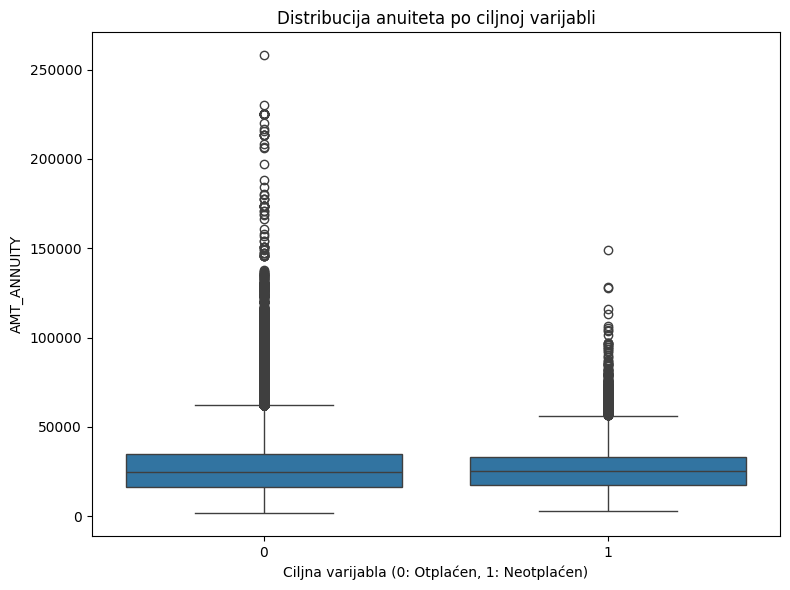


Prosječni 'AMT_ANNUITY' po TARGET varijabli:
TARGET
0   27163.53
1   26481.74
Name: AMT_ANNUITY, dtype: float64

Medijan 'AMT_ANNUITY' po TARGET varijabli:
TARGET
0   24876.00
1   25263.00
Name: AMT_ANNUITY, dtype: float64


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

print("# 13.4. Analiza anuiteta (AMT_ANNUITY) po ciljnoj varijabli")

plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='AMT_ANNUITY', data=df_application_train)
plt.title('Distribucija anuiteta po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('AMT_ANNUITY')
plt.tight_layout()
plt.show()

print("\nProsječni 'AMT_ANNUITY' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['AMT_ANNUITY'].mean())

print("\nMedijan 'AMT_ANNUITY' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['AMT_ANNUITY'].median())

### 13.5. Analiza broja djece (CNT_CHILDREN) po ciljnoj varijabli

# 13.5. Analiza broja djece (CNT_CHILDREN) po ciljnoj varijabli


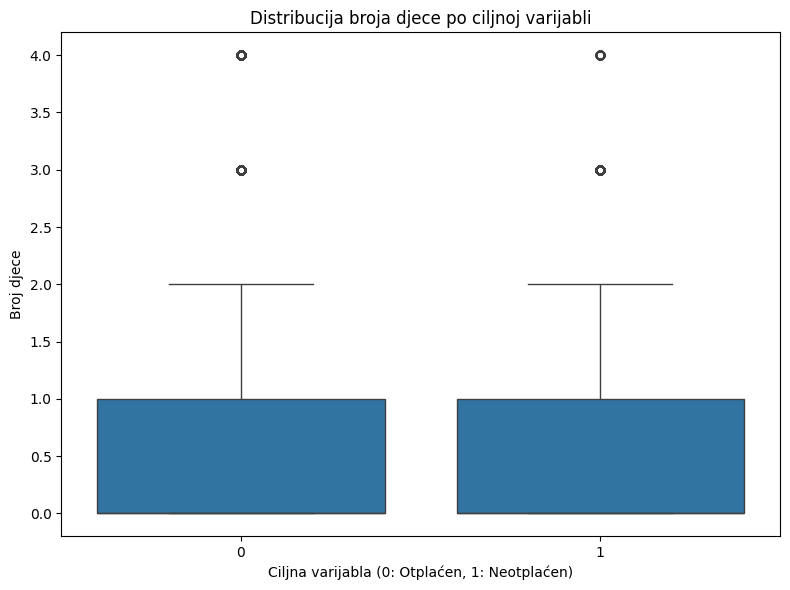


Prosječni 'CNT_CHILDREN' po TARGET varijabli:
TARGET
0   0.41
1   0.46
Name: CNT_CHILDREN, dtype: float64

Medijan 'CNT_CHILDREN' po TARGET varijabli:
TARGET
0   0.00
1   0.00
Name: CNT_CHILDREN, dtype: float64


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

print("# 13.5. Analiza broja djece (CNT_CHILDREN) po ciljnoj varijabli")

plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='CNT_CHILDREN', data=df_application_train)
plt.title('Distribucija broja djece po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Broj djece')
plt.tight_layout()
plt.show()

print("\nProsječni 'CNT_CHILDREN' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['CNT_CHILDREN'].mean())

print("\nMedijan 'CNT_CHILDREN' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['CNT_CHILDREN'].median())

### 13.6. Analiza relativne populacije regije (REGION_POPULATION_RELATIVE) po ciljnoj varijabli

# 13.6. Analiza relativne populacije regije (REGION_POPULATION_RELATIVE) po ciljnoj varijabli


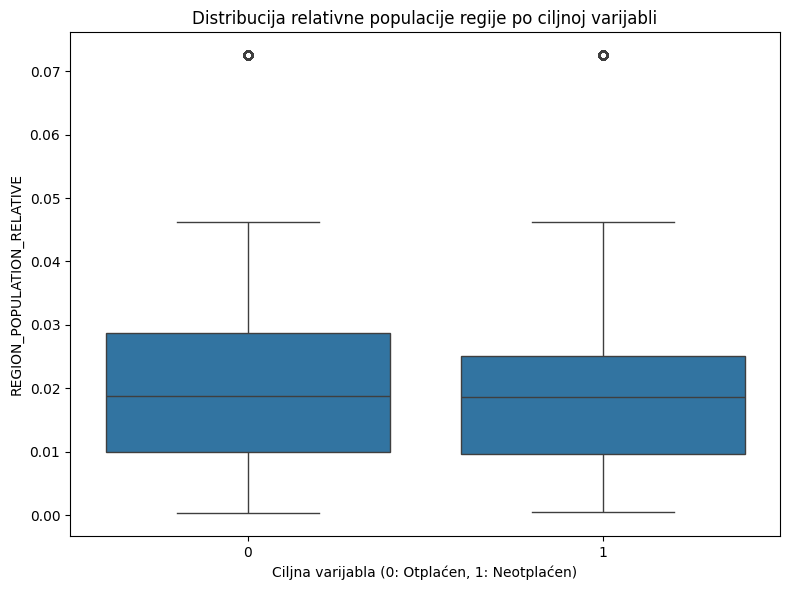


Prosječni 'REGION_POPULATION_RELATIVE' po TARGET varijabli:
TARGET
0   0.02
1   0.02
Name: REGION_POPULATION_RELATIVE, dtype: float64

Medijan 'REGION_POPULATION_RELATIVE' po TARGET varijabli:
TARGET
0   0.02
1   0.02
Name: REGION_POPULATION_RELATIVE, dtype: float64


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

print("# 13.6. Analiza relativne populacije regije (REGION_POPULATION_RELATIVE) po ciljnoj varijabli")

plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='REGION_POPULATION_RELATIVE', data=df_application_train)
plt.title('Distribucija relativne populacije regije po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('REGION_POPULATION_RELATIVE')
plt.tight_layout()
plt.show()

print("\nProsječni 'REGION_POPULATION_RELATIVE' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['REGION_POPULATION_RELATIVE'].mean())

print("\nMedijan 'REGION_POPULATION_RELATIVE' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['REGION_POPULATION_RELATIVE'].median())

### 13.7. Analiza posjedovanja automobila (FLAG_OWN_CAR) po ciljnoj varijabli

# 13.7. Analiza posjedovanja automobila (FLAG_OWN_CAR) po ciljnoj varijabli


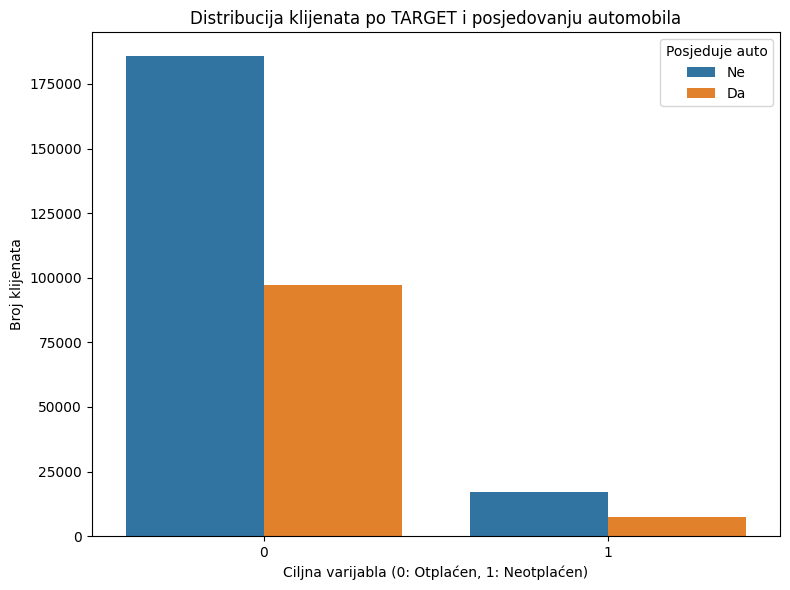


Distribucija 'FLAG_OWN_CAR':
FLAG_OWN_CAR
0   65.99
1   34.01
Name: proportion, dtype: float64

Postotak klijenata s TARGET=0 (otplaćen kredit) koji posjeduju automobil:
FLAG_OWN_CAR
0   65.68
1   34.32
Name: proportion, dtype: float64

Postotak klijenata s TARGET=1 (neotplaćen kredit) koji posjeduju automobil:
FLAG_OWN_CAR
0   69.48
1   30.52
Name: proportion, dtype: float64


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

print("# 13.7. Analiza posjedovanja automobila (FLAG_OWN_CAR) po ciljnoj varijabli")

plt.figure(figsize=(8, 6))
sns.countplot(x='TARGET', hue='FLAG_OWN_CAR', data=df_application_train)
plt.title('Distribucija klijenata po TARGET i posjedovanju automobila')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Broj klijenata')
plt.xticks(ticks=[0, 1], labels=['0', '1'])
plt.legend(title='Posjeduje auto', labels=['Ne', 'Da'])
plt.tight_layout()
plt.show()

print("\nDistribucija 'FLAG_OWN_CAR':")
print(df_application_train['FLAG_OWN_CAR'].value_counts(normalize=True) * 100)

target_0_data = df_application_train[df_application_train['TARGET'] == 0]
car_ownership_target_0 = target_0_data['FLAG_OWN_CAR'].value_counts(normalize=True) * 100
print(f"\nPostotak klijenata s TARGET=0 (otplaćen kredit) koji posjeduju automobil:\n{car_ownership_target_0}")

target_1_data = df_application_train[df_application_train['TARGET'] == 1]
car_ownership_target_1 = target_1_data['FLAG_OWN_CAR'].value_counts(normalize=True) * 100
print(f"\nPostotak klijenata s TARGET=1 (neotplaćen kredit) koji posjeduju automobil:\n{car_ownership_target_1}")


### 13.8. Analiza posjedovanja nekretnine (FLAG_OWN_REALTY) po ciljnoj varijabli

# 13.8. Analiza posjedovanja nekretnine (FLAG_OWN_REALTY) po ciljnoj varijabli


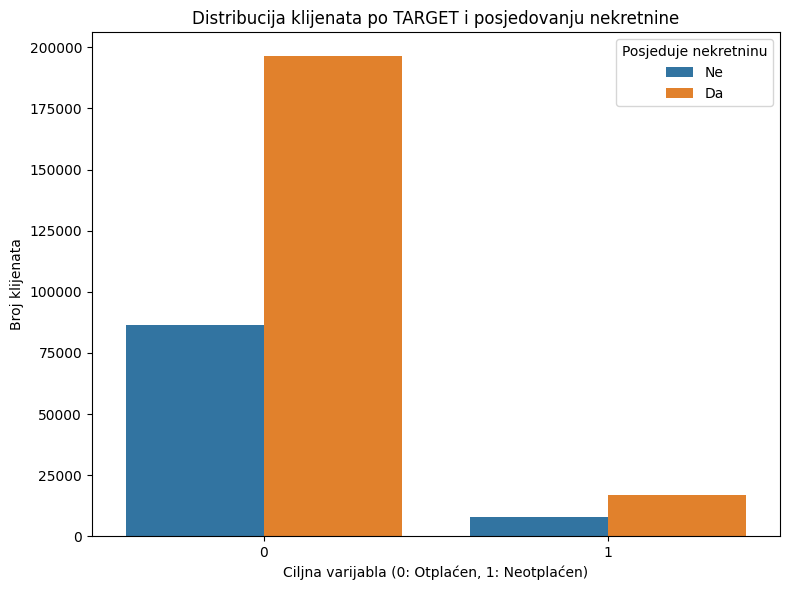


Distribucija 'FLAG_OWN_REALTY':
FLAG_OWN_REALTY
1   69.37
0   30.63
Name: proportion, dtype: float64

Postotak klijenata s TARGET=0 (otplaćen kredit) koji posjeduju nekretninu:
FLAG_OWN_REALTY
1   69.45
0   30.55
Name: proportion, dtype: float64

Postotak klijenata s TARGET=1 (neotplaćen kredit) koji posjeduju nekretninu:
FLAG_OWN_REALTY
1   68.41
0   31.59
Name: proportion, dtype: float64


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

print("# 13.8. Analiza posjedovanja nekretnine (FLAG_OWN_REALTY) po ciljnoj varijabli")

plt.figure(figsize=(8, 6))
sns.countplot(x='TARGET', hue='FLAG_OWN_REALTY', data=df_application_train)
plt.title('Distribucija klijenata po TARGET i posjedovanju nekretnine')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Broj klijenata')
plt.xticks(ticks=[0, 1], labels=['0', '1'])
plt.legend(title='Posjeduje nekretninu', labels=['Ne', 'Da'])
plt.tight_layout()
plt.show()

print("\nDistribucija 'FLAG_OWN_REALTY':")
print(df_application_train['FLAG_OWN_REALTY'].value_counts(normalize=True) * 100)

target_0_data = df_application_train[df_application_train['TARGET'] == 0]
realty_ownership_target_0 = target_0_data['FLAG_OWN_REALTY'].value_counts(normalize=True) * 100
print(f"\nPostotak klijenata s TARGET=0 (otplaćen kredit) koji posjeduju nekretninu:\n{realty_ownership_target_0}")

target_1_data = df_application_train[df_application_train['TARGET'] == 1]
realty_ownership_target_1 = target_1_data['FLAG_OWN_REALTY'].value_counts(normalize=True) * 100
print(f"\nPostotak klijenata s TARGET=1 (neotplaćen kredit) koji posjeduju nekretninu:\n{realty_ownership_target_1}")

### 13.9. Analiza nezaposlenih/umirovljenih klijenata (UNEMPLOYED_RETIRED) po ciljnoj varijabli

# 13.9. Analiza nezaposlenih/umirovljenih klijenata (UNEMPLOYED_RETIRED) po ciljnoj varijabli


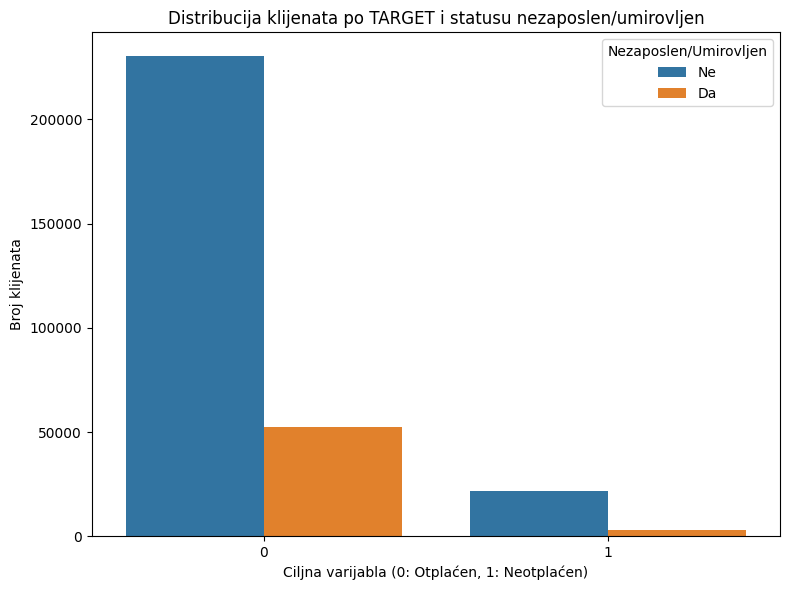


Distribucija 'UNEMPLOYED_RETIRED':
UNEMPLOYED_RETIRED
0   81.99
1   18.01
Name: proportion, dtype: float64

Postotak klijenata s TARGET=0 (otplaćen kredit) koji su nezaposleni/umirovljeni:
UNEMPLOYED_RETIRED
0   81.47
1   18.53
Name: proportion, dtype: float64

Postotak klijenata s TARGET=1 (neotplaćen kredit) koji su nezaposleni/umirovljeni:
UNEMPLOYED_RETIRED
0   87.96
1   12.04
Name: proportion, dtype: float64


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

print("# 13.9. Analiza nezaposlenih/umirovljenih klijenata (UNEMPLOYED_RETIRED) po ciljnoj varijabli")

plt.figure(figsize=(8, 6))
sns.countplot(x='TARGET', hue='UNEMPLOYED_RETIRED', data=df_application_train)
plt.title('Distribucija klijenata po TARGET i statusu nezaposlen/umirovljen')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Broj klijenata')
plt.xticks(ticks=[0, 1], labels=['0', '1'])
plt.legend(title='Nezaposlen/Umirovljen', labels=['Ne', 'Da'])
plt.tight_layout()
plt.show()

print("\nDistribucija 'UNEMPLOYED_RETIRED':")
print(df_application_train['UNEMPLOYED_RETIRED'].value_counts(normalize=True) * 100)

target_0_data = df_application_train[df_application_train['TARGET'] == 0]
unemployed_retired_target_0 = target_0_data['UNEMPLOYED_RETIRED'].value_counts(normalize=True) * 100
print(f"\nPostotak klijenata s TARGET=0 (otplaćen kredit) koji su nezaposleni/umirovljeni:\n{unemployed_retired_target_0}")

target_1_data = df_application_train[df_application_train['TARGET'] == 1]
unemployed_retired_target_1 = target_1_data['UNEMPLOYED_RETIRED'].value_counts(normalize=True) * 100
print(f"\nPostotak klijenata s TARGET=1 (neotplaćen kredit) koji su nezaposleni/umirovljeni:\n{unemployed_retired_target_1}")


# 13.10. CNT_FAM_MEMBERS

# 13.10. Analiza broja članova obitelji (CNT_FAM_MEMBERS) po ciljnoj varijabli


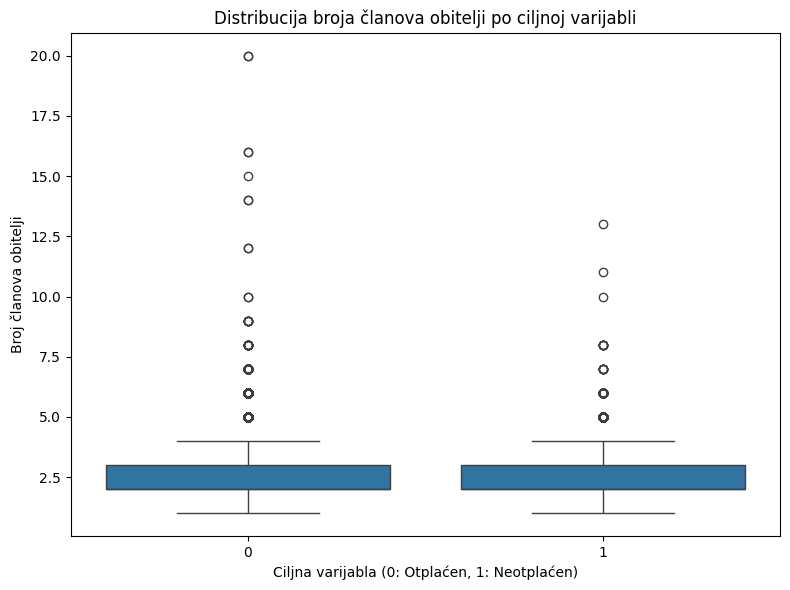


Prosječni 'CNT_FAM_MEMBERS' po TARGET varijabli:
TARGET
0   2.15
1   2.18
Name: CNT_FAM_MEMBERS, dtype: float64

Medijan 'CNT_FAM_MEMBERS' po TARGET varijabli:
TARGET
0   2.00
1   2.00
Name: CNT_FAM_MEMBERS, dtype: float64


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

print("# 13.10. Analiza broja članova obitelji (CNT_FAM_MEMBERS) po ciljnoj varijabli")

plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='CNT_FAM_MEMBERS', data=df_application_train)
plt.title('Distribucija broja članova obitelji po ciljnoj varijabli')
plt.xlabel('Ciljna varijabla (0: Otplaćen, 1: Neotplaćen)')
plt.ylabel('Broj članova obitelji')
plt.tight_layout()
plt.show()

print("\nProsječni 'CNT_FAM_MEMBERS' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['CNT_FAM_MEMBERS'].mean())

print("\nMedijan 'CNT_FAM_MEMBERS' po TARGET varijabli:")
print(df_application_train.groupby('TARGET')['CNT_FAM_MEMBERS'].median())

# 14. Spremanje dataframe-ova u drive

In [66]:
from google.colab import drive
import os

drive.mount('/content/drive')

save_directory = '/content/drive/MyDrive/processed_dataframes'

if not os.path.exists(save_directory):
    os.makedirs(save_directory)
    print(f"Directory '{save_directory}' created.")
else:
    print(f"Directory '{save_directory}' already exists.")

df_application_train.to_csv(os.path.join(save_directory, 'df_application_train_processed.csv'), index=False)
df_bureau.to_csv(os.path.join(save_directory, 'df_bureau_processed.csv'), index=False)
df_previous_application.to_csv(os.path.join(save_directory, 'df_previous_application_processed.csv'), index=False)
df_installments_payments.to_csv(os.path.join(save_directory, 'df_installments_payments_processed.csv'), index=False)

print(f"All DataFrames saved to '{save_directory}'")

Mounted at /content/drive
Directory '/content/drive/MyDrive/processed_dataframes' already exists.
All DataFrames saved to '/content/drive/MyDrive/processed_dataframes'
